In [1]:
# =============================================================================
# ЯЧЕЙКА 1: УСТАНОВКА ЗАВИСИМОСТЕЙ И ИМПОРТЫ
# =============================================================================

!pip install geopandas shapely scipy numpy pandas

import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon, MultiPolygon
from shapely.ops import unary_union
from scipy.spatial.distance import cdist
from typing import Dict, List, Tuple, Optional, Set, Any
from dataclasses import dataclass, field
from abc import ABC, abstractmethod
from numpy.typing import ArrayLike
import warnings
warnings.filterwarnings('ignore')

print("✓ Все библиотеки успешно импортированы")

✓ Все библиотеки успешно импортированы


Тайцы

In [ ]:
# =============================================================================
# ЯЧЕЙКА 2: НОРМАТИВЫ И КОНФИГУРАЦИЯ
# =============================================================================

# Нормативы сервисов
SERVICE_STANDARDS = {
    'school': {
        'demand': 60,              # мест на 1000 жителей
        'accessibility': 90,       # минут пешком
        'type': 'capacity',
        'functional_zone': 'ОД2',
        'can_be_in_residential': False,
        'priority': 1,
        'area_rules': [
            {'max_capacity': 400, 'sqm_per_unit': 55},
            {'max_capacity': 500, 'sqm_per_unit': 66},
            {'max_capacity': 600, 'sqm_per_unit': 55},
            {'max_capacity': 800, 'sqm_per_unit': 44},
            {'max_capacity': 1100, 'sqm_per_unit': 36},
            {'max_capacity': float('inf'), 'sqm_per_unit': 24}
        ]
    },
    'kindergarten': {
        'demand': 40,
        'accessibility': 30,
        'type': 'capacity',
        'functional_zone': 'ОД2',
        'can_be_in_residential': True,
        'priority': 1,
        'area_rules': [
            {'max_capacity': 100, 'sqm_per_unit': 45},
            {'max_capacity': float('inf'), 'sqm_per_unit': 40}
        ]
    },
    'polyclinic': {
        'demand': 15,
        'accessibility': 180,
        'type': 'capacity',
        'functional_zone': 'ОД2',
        'can_be_in_residential': False,
        'priority': 2,
        'area_min': 3000,
        'area_max': 5000
    },
    'sport_centre': {
        'demand': None,
        'accessibility': 120,
        'type': 'single',
        'functional_zone': 'ОД2',
        'can_be_in_residential': False,
        'priority': 3,
        'area_min': 3500,
        'area_max': 5000
    },
    'music_school': {
        'demand': 6,
        'accessibility': 120,
        'type': 'capacity',
        'functional_zone': 'ОД2',
        'can_be_in_residential': False,
        'priority': 6,
        'area_min': 1000,
        'area_max': 3000
    },
    'cafe': {
        'demand': 50,
        'accessibility': 40,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 5,
        'area_min': 1000,
        'area_max': 2000
    },
    'post_office': {
        'demand': None,            # 1 на всё население
        'accessibility': 200,
        'type': 'single',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 3,
        'area_min': 800,
        'area_max': 1000
    },
    'supermarket': {
        'demand': 486,
        'accessibility': 30,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': True,
        'priority': 2,
        'area_min': 1000,
        'area_max': 3000
    },
    'library': {
        'demand': 10,
        'accessibility': 200,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 4,
        'area_min': 1000,
        'area_max': 3000
    },
    'community_centre': {
        'demand': 10,
        'accessibility': 200,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 3,
        'area_min': 1000,
        'area_max': 3000
    },
    'pharmacy': {
        'demand': 50,
        'accessibility': 20,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': True,
        'priority': 2,
        'area_min': 200,
        'area_max': 500
    },
    'police': {
        'demand': None,
        'accessibility': 200,
        'type': 'single',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 2,
        'area_min': 1000,
        'area_max': 2000
    },
    'fire_station': {
        'demand': None,
        'accessibility': 200,
        'type': 'single',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 1,
        'area_min': 1000,
        'area_max': 3000,
        'special_placement': 'near_road_away_from_population'
    },
    'park': {
        'demand': 10000,           # кв.м на 1000 жителей
        'accessibility': 10,
        'type': 'area',            # площадной объект
        'functional_zone': 'Р1',
        'can_be_in_residential': False,
        'priority': 2,
        'area_min': 1000,
        'area_max': 35000
    },
    'parking': {
        'demand': 20,
        'accessibility': None,
        'type': 'capacity',
        'functional_zone': 'Т',
        'can_be_in_residential': False,
        'priority': 3,
        'area_min': 3000,
        'area_max': 5000,
        'special_placement': 'near_railway'
    }
}

# Приоритет функциональных зон
FZ_PRIORITY = {
    'ОД2': 1,
    'ОД': 2,
    'Р1': 3,
    'Т': 4,
    'ЗН': 5,
    'НЗ': 6
}

# Жилые зоны
RESIDENTIAL_ZONES = ['Ж1', 'Ж2', 'Ж-1', 'Ж-2', 'Жилая']

# Производственные зоны
INDUSTRIAL_ZONES = ['П', 'П1', 'П2', 'П-1', 'П-2', 'Производственная']

print("✓ Нормативы сервисов загружены")
print(f"  - Типов сервисов: {len(SERVICE_STANDARDS)}")

✓ Нормативы сервисов загружены
  - Типов сервисов: 15


Кузьмолово

In [2]:
# =============================================================================
# ЯЧЕЙКА 2: НОРМАТИВЫ И КОНФИГУРАЦИЯ Кузьмолово
# =============================================================================

# Нормативы сервисов
SERVICE_STANDARDS = {
    'school': {
        'demand': 100,              # мест на 1000 жителей
        'accessibility': 30,       # минут пешком
        'type': 'capacity',
        'functional_zone': 'ОД2',
        'can_be_in_residential': True,
        'priority': 1,
        'area_rules': [
            {'max_capacity': 400, 'sqm_per_unit': 55},
            {'max_capacity': 500, 'sqm_per_unit': 66},
            {'max_capacity': 600, 'sqm_per_unit': 55},
            {'max_capacity': 800, 'sqm_per_unit': 44},
            {'max_capacity': 1100, 'sqm_per_unit': 36},
            {'max_capacity': float('inf'), 'sqm_per_unit': 24}
        ]
    },
    'kindergarten': {
        'demand': 61,
        'accessibility': 20,
        'type': 'capacity',
        'functional_zone': 'ОД2',
        'can_be_in_residential': True,
        'priority': 1,
        'area_rules': [
            {'max_capacity': 100, 'sqm_per_unit': 45},
            {'max_capacity': float('inf'), 'sqm_per_unit': 40}
        ]
    },
    'polyclinic': {
        'demand': 15,
        'accessibility': 180,
        'type': 'capacity',
        'functional_zone': 'ОД2',
        'can_be_in_residential': True,
        'priority': 2,
        'area_min': 3000,
        'area_max': 5000
    },
    'sport_centre': {
        'demand': None,
        'accessibility': 120,
        'type': 'single',
        'functional_zone': 'ОД2',
        'can_be_in_residential': False,
        'priority': 3,
        'area_min': 3500,
        'area_max': 5000
    },

    'cafe': {
        'demand': 50,
        'accessibility': 40,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 7,
        'area_min': 1000,
        'area_max': 2000
    },
    'post_office': {
        'demand': None,            # 1 на всё население
        'accessibility': 200,
        'type': 'single',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 5,
        'area_min': 800,
        'area_max': 1000
    },
    'supermarket': {
        'demand': 486,
        'accessibility': 30,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': True,
        'priority': 5,
        'area_min': 1000,
        'area_max': 3000
    },
    'library': {
        'demand': 10,
        'accessibility': 200,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 5,
        'area_min': 1000,
        'area_max': 3000
    },
    'community_centre': {
        'demand': 10,
        'accessibility': 200,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 3,
        'area_min': 1000,
        'area_max': 3000
    },
    'pharmacy': {
        'demand': 50,
        'accessibility': 20,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': True,
        'priority': 2,
        'area_min': 200,
        'area_max': 500
    },
    'police': {
        'demand': None,
        'accessibility': 200,
        'type': 'single',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 7,
        'area_min': 1000,
        'area_max': 2000
    },
    'fire_station': {
        'demand': None,
        'accessibility': 200,
        'type': 'single',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 7,
        'area_min': 1000,
        'area_max': 3000,
        'special_placement': 'near_road_away_from_population'
    },
    'park': {
        'demand': 150,           # кв.м на 1000 жителей
        'accessibility': 30,
        'type': 'area',            # площадной объект
        'functional_zone': 'Р1',
        'can_be_in_residential': False,
        'priority': 6,
        'area_min': 1000,
        'area_max': 35000
    },
    'parking': {
        'demand': 100,
        'accessibility': None,
        'type': 'capacity',
        'functional_zone': 'Т',
        'can_be_in_residential': False,
        'priority': 2,
        'area_min': 3000,
        'area_max': 5000,
        'special_placement': 'near_railway'
    }
}

# Приоритет функциональных зон
FZ_PRIORITY = {
    'ОД2': 1,
    'ОД': 3,
    'Р1': 4,
    'Т': 2,
    'ЗН': 5,
    'НЗ': 6
}

# Жилые зоны
RESIDENTIAL_ZONES = ['Ж1', 'Ж2', 'Ж3', 'Ж4']

# Производственные зоны
INDUSTRIAL_ZONES = ['П', 'П1', 'П2', 'П-1', 'П-2', 'Производственная']

print("✓ Нормативы сервисов загружены")
print(f"  - Типов сервисов: {len(SERVICE_STANDARDS)}")

✓ Нормативы сервисов загружены
  - Типов сервисов: 14


Шлиссельбург

In [4]:
# =============================================================================
# ЯЧЕЙКА 2: НОРМАТИВЫ И КОНФИГУРАЦИЯ Шлиссельбург
# =============================================================================

# Нормативы сервисов
SERVICE_STANDARDS = {
    'school': {
        'demand': 60,              # мест на 1000 жителей
        'accessibility': 90,       # минут пешком
        'type': 'capacity',
        'functional_zone': 'ОД2',
        'can_be_in_residential': False,
        'priority': 1,
        'area_rules': [
            {'max_capacity': 400, 'sqm_per_unit': 55},
            {'max_capacity': 500, 'sqm_per_unit': 66},
            {'max_capacity': 600, 'sqm_per_unit': 55},
            {'max_capacity': 800, 'sqm_per_unit': 44},
            {'max_capacity': 1100, 'sqm_per_unit': 36},
            {'max_capacity': float('inf'), 'sqm_per_unit': 24}
        ]
    },
    'kindergarten': {
        'demand': 40,
        'accessibility': 30,
        'type': 'capacity',
        'functional_zone': 'ОД2',
        'can_be_in_residential': True,
        'priority': 1,
        'area_rules': [
            {'max_capacity': 100, 'sqm_per_unit': 45},
            {'max_capacity': float('inf'), 'sqm_per_unit': 40}
        ]
    },
    'polyclinic': {
        'demand': 15,
        'accessibility': 180,
        'type': 'capacity',
        'functional_zone': 'ОД2',
        'can_be_in_residential': False,
        'priority': 2,
        'area_min': 3000,
        'area_max': 5000
    },
    'sport_centre': {
        'demand': None,
        'accessibility': 120,
        'type': 'single',
        'functional_zone': 'ОД2',
        'can_be_in_residential': False,
        'priority': 3,
        'area_min': 3500,
        'area_max': 5000
    },
    'hotel': {
        'demand': 10,
        'accessibility': 60,
        'type': 'capacity',
        'functional_zone': 'ОД2',
        'can_be_in_residential': True,
        'priority': 5,
        'area_min': 1000,
        'area_max': 3000
    },
    'cafe': {
        'demand': 50,
        'accessibility': 40,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 5,
        'area_min': 1000,
        'area_max': 2000
    },
    'post_office': {
        'demand': None,            # 1 на всё население
        'accessibility': 200,
        'type': 'single',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 3,
        'area_min': 800,
        'area_max': 1000
    },
    'supermarket': {
        'demand': 486,
        'accessibility': 30,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': True,
        'priority': 2,
        'area_min': 1000,
        'area_max': 3000
    },
    'library': {
        'demand': 10,
        'accessibility': 200,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 4,
        'area_min': 1000,
        'area_max': 3000
    },
    'community_centre': {
        'demand': 10,
        'accessibility': 200,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 3,
        'area_min': 1000,
        'area_max': 3000
    },
    'pharmacy': {
        'demand': 50,
        'accessibility': 20,
        'type': 'capacity',
        'functional_zone': 'ОД',
        'can_be_in_residential': True,
        'priority': 2,
        'area_min': 200,
        'area_max': 500
    },
    'police': {
        'demand': None,
        'accessibility': 200,
        'type': 'single',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 2,
        'area_min': 1000,
        'area_max': 2000
    },
    'fire_station': {
        'demand': None,
        'accessibility': 200,
        'type': 'single',
        'functional_zone': 'ОД',
        'can_be_in_residential': False,
        'priority': 1,
        'area_min': 1000,
        'area_max': 3000,
        'special_placement': 'near_road_away_from_population'
    },
    'park': {
        'demand': 150,           # кв.м на 1000 жителей
        'accessibility': 30,
        'type': 'area',            # площадной объект
        'functional_zone': 'Р1',
        'can_be_in_residential': True,
        'priority': 2,
        'area_min': 1000,
        'area_max': 35000
    },
    'parking': {
        'demand': 100,
        'accessibility': None,
        'type': 'capacity',
        'functional_zone': 'Т',
        'can_be_in_residential': False,
        'priority': 7,
        'area_min': 3000,
        'area_max': 5000,
        'special_placement': 'near_railway'
    }
}

# Приоритет функциональных зон
FZ_PRIORITY = {
    'ОД2': 1,
    'ОД': 3,
    'Р1': 2,
    'Т': 4,
    'ЗН': 5,
    'НЗ': 6
}

# Жилые зоны
RESIDENTIAL_ZONES = ['Ж1', 'Ж2', 'Ж3', 'Ж4']

# Производственные зоны
INDUSTRIAL_ZONES = ['П', 'П1', 'П2', 'П-1', 'П-2', 'Производственная']

print("✓ Нормативы сервисов загружены")
print(f"  - Типов сервисов: {len(SERVICE_STANDARDS)}")

✓ Нормативы сервисов загружены
  - Типов сервисов: 15


In [6]:
# =============================================================================
# ЯЧЕЙКА 3: ЗАГРУЗКА ДАННЫХ
# =============================================================================

# Пути к файлам (измените на свои)
BLOCKS_PATH = 'blocks_provision.geojson'
BLOCKSNET_PATH = 'blocksnet.geojson'
PARCELS_PATH = 'potential_parcels.geojson'
ZONES_PATH = 'functional_zones.geojson'
ZOUIT_PATH = 'zouit.geojson'
RAIL_STATION_PATH = '/content/railway_stations.geojson'

# Загрузка данных
print("Загрузка данных...")

blocks = gpd.read_file(BLOCKS_PATH)
blocksnet = gpd.read_file(BLOCKSNET_PATH)
parcels = gpd.read_file(PARCELS_PATH)
functional_zones = gpd.read_file(ZONES_PATH)
zouit = gpd.read_file(ZOUIT_PATH)
rail_station = gpd.read_file(RAIL_STATION_PATH)

# ПРИВЕДЕНИЕ К ЕДИНОЙ CRS
# =============================================================================

print("\n🔄 Приведение к единой системе координат...")

# Определяем целевую CRS (берём из blocks или задаём явно)
# Для Ленинградской области обычно используется EPSG:32636 (UTM 36N) или EPSG:32635 (UTM 35N)

# Вариант 1: Берём CRS из основного слоя
TARGET_CRS = blocks.crs

# Вариант 2: Если blocks в WGS84, используем метрическую проекцию
if blocks.crs is None or blocks.crs.is_geographic:
    # Для Ленинградской области (около 30° в.д.) подходит UTM 36N
    TARGET_CRS = "EPSG:32636"
    print(f"  ⚠ Основной слой в географических координатах!")
    print(f"  → Используем проекцию: {TARGET_CRS}")
    blocks = blocks.to_crs(TARGET_CRS)

print(f"  Целевая CRS: {TARGET_CRS}")

# Преобразуем все слои
layers_to_transform = {
    'blocksnet': blocksnet,
    'parcels': parcels,
    'functional_zones': functional_zones,
    'zouit': zouit,
    'rail_station': rail_station
}

for name, gdf in layers_to_transform.items():
    if gdf.crs is None:
        print(f"  ⚠ {name}: CRS не определена, пропускаем")
        continue

    if gdf.crs != TARGET_CRS:
        print(f"  → {name}: {gdf.crs} → {TARGET_CRS}")

        # Преобразуем
        if name == 'blocksnet':
            blocksnet = gdf.to_crs(TARGET_CRS)
        elif name == 'parcels':
            parcels = gdf.to_crs(TARGET_CRS)
        elif name == 'functional_zones':
            functional_zones = gdf.to_crs(TARGET_CRS)
        elif name == 'zouit':
            zouit = gdf.to_crs(TARGET_CRS)
        elif name == 'rail_station':
            rail_station = gdf.to_crs(TARGET_CRS)
    else:
        print(f"  ✓ {name}: CRS совпадает")

# =============================================================================
# ПРОВЕРКА ПОСЛЕ ПРЕОБРАЗОВАНИЯ
# =============================================================================

print("\n📐 Проверка координат после преобразования:")

if len(rail_station) > 0 and len(parcels) > 0:
    station = rail_station.geometry.iloc[0]
    station_pt = station.centroid if hasattr(station, 'centroid') else station

    parcel_pt = parcels.geometry.iloc[0].centroid

    distance = station_pt.distance(parcel_pt)

    print(f"  Станция: X={station_pt.x:.0f}, Y={station_pt.y:.0f}")
    print(f"  Участок: X={parcel_pt.x:.0f}, Y={parcel_pt.y:.0f}")
    print(f"  Расстояние: {distance:.0f} м")

    if distance > 100000:  # > 100 км
        print(f"  ⚠ ВНИМАНИЕ: Расстояние слишком большое!")
        print(f"    Возможно, слои всё ещё в разных CRS или данные некорректны")
    else:
        print(f"  ✓ Расстояние в пределах нормы")

# Добавление идентификаторов
if 'block_id' not in blocks.columns:
    blocks['block_id'] = range(len(blocks))
if 'parcel_id' not in parcels.columns:
    parcels['parcel_id'] = range(len(parcels))

print(f"✓ Данные загружены:")
print(f"  - Кварталов: {len(blocks)}")
print(f"  - Свободных участков: {len(parcels)}")
print(f"  - Функциональных зон: {len(functional_zones)}")
print(f"  - ЗОУИТ: {len(zouit)}")
print(f"  - ЖД станций: {len(rail_station)}")

# Показать структуру данных
print(f"\nСтолбцы blocks: {list(blocks.columns)}")
print(f"Столбцы parcels: {list(parcels.columns)}")

Загрузка данных...

🔄 Приведение к единой системе координат...
  ⚠ Основной слой в географических координатах!
  → Используем проекцию: EPSG:32636
  Целевая CRS: EPSG:32636
  → blocksnet: EPSG:4326 → EPSG:32636
  → parcels: EPSG:3857 → EPSG:32636
  → functional_zones: EPSG:3857 → EPSG:32636
  → zouit: EPSG:3857 → EPSG:32636
  → rail_station: EPSG:4326 → EPSG:32636

📐 Проверка координат после преобразования:
  Станция: X=386236, Y=6645033
  Участок: X=387977, Y=6644763
  Расстояние: 1761 м
  ✓ Расстояние в пределах нормы
✓ Данные загружены:
  - Кварталов: 152
  - Свободных участков: 58
  - Функциональных зон: 285
  - ЗОУИТ: 284
  - ЖД станций: 3

Столбцы blocks: ['residential', 'business', 'recreation', 'industrial', 'transport', 'special', 'agriculture', 'land_use', 'share', 'is_living', 'number_of_floors', 'footprint_area', 'build_floor_area', 'living_area', 'non_living_area', 'population', 'count', 'capacity_pharmacy', 'count_pharmacy', 'capacity_library', 'count_library', 'capacity_

In [7]:
# =============================================================================
# ЯЧЕЙКА 4: СТРУКТУРЫ ДАННЫХ
# =============================================================================
# Адаптировано под структуру полей BlocksNet в blocks_provision.geojson:
# - demand_{service}, capacity_{service}
# - demand_left_{service}, demand_within_{service}, demand_without_{service}
# - capacity_left_{service}, capacity_within_{service}, capacity_without_{service}
# - provision_strong_{service}, provision_weak_{service}
#
# ЛОГИКА ЗОУИТ:
# - Зона 'ЗН' (Озеленение специального назначения) назначается ТОЛЬКО если
#   участок пересекает ОПАСНУЮ зону ЗОУИТ (is_hazard = 1)
# - Неопасные ЗОУИТ (is_hazard = 0) не влияют на назначение функциональной зоны
# =============================================================================

from dataclasses import dataclass, field
from typing import List, Any, Dict, Optional, Tuple
from enum import Enum
import numpy as np
import pandas as pd


# =============================================================================
# ПЕРЕЧИСЛЕНИЯ
# =============================================================================

class ProvisionType(Enum):
    """Тип расчёта обеспеченности"""
    STRONG = "strong"  # Строгая - только объекты в зоне доступности
    WEAK = "weak"      # Слабая - все объекты с весами по расстоянию


class DeficitSeverityLevel(Enum):
    """Уровень тяжести дефицита"""
    NONE = "none"           # Нет дефицита (>= 80%)
    LOW = "low"             # Низкий (60-80%)
    MEDIUM = "medium"       # Средний (40-60%)
    HIGH = "high"           # Высокий (20-40%)
    CRITICAL = "critical"   # Критический (< 20%)


class ZouitType(Enum):
    """Тип зоны ЗОУИТ"""
    NONE = 0           # Не пересекает ЗОУИТ
    SAFE = 1           # Неопасная ЗОУИТ (is_hazard = 0) - можно строить
    HAZARD = 2         # Опасная ЗОУИТ (is_hazard = 1) - только ЗН


# =============================================================================
# КЛАСС ServiceDeficit - ДЕФИЦИТ СЕРВИСА
# =============================================================================

@dataclass
class ServiceDeficit:
    """
    Информация о дефиците сервиса в конкретном квартале.

    Интегрируется с полями BlocksNet из blocks_provision.geojson:
    - demand_{service}           : общий спрос квартала на сервис
    - capacity_{service}         : общая вместимость сервисов
    - demand_left_{service}      : неудовлетворённый спрос
    - demand_within_{service}    : спрос, покрываемый объектами в зоне доступности
    - demand_without_{service}   : спрос вне зоны доступности объектов
    - capacity_left_{service}    : неиспользованная вместимость
    - capacity_within_{service}  : вместимость объектов в зоне доступности
    - capacity_without_{service} : вместимость объектов вне зоны доступности
    - provision_strong_{service} : строгая обеспеченность (только в зоне доступности)
    - provision_weak_{service}   : слабая обеспеченность (с учётом всех объектов)

    Attributes
    ----------
    service_type : str
        Тип сервиса ('school', 'kindergarten', 'park', etc.)
    block_id : int
        Идентификатор квартала
    demand : float
        Общий спрос квартала (demand_{service})
    capacity : float
        Общая вместимость (capacity_{service})
    demand_left : float
        Неудовлетворённый спрос (demand_left_{service})
    demand_within : float
        Спрос в зоне доступности (demand_within_{service})
    demand_without : float
        Спрос вне зоны доступности (demand_without_{service})
    capacity_left : float
        Свободная вместимость (capacity_left_{service})
    capacity_within : float
        Вместимость в зоне доступности (capacity_within_{service})
    capacity_without : float
        Вместимость вне зоны доступности (capacity_without_{service})
    provision_strong : float
        Строгая обеспеченность 0-1 (provision_strong_{service})
    provision_weak : float
        Слабая обеспеченность 0-1 (provision_weak_{service})
    deficit_severity : float
        Тяжесть дефицита 0-1 (рассчитывается автоматически)
    required_capacity : float
        Необходимая дополнительная вместимость (рассчитывается автоматически)
    priority_score : float
        Приоритет устранения дефицита (рассчитывается автоматически)
    """

    # === ОБЯЗАТЕЛЬНЫЕ ПОЛЯ ===
    service_type: str
    block_id: int

    # === ДАННЫЕ СПРОСА ИЗ BLOCKS_PROVISION ===
    demand: float                        # demand_{service}
    demand_left: float = 0.0             # demand_left_{service}
    demand_within: float = 0.0           # demand_within_{service}
    demand_without: float = 0.0          # demand_without_{service}

    # === ДАННЫЕ ВМЕСТИМОСТИ ИЗ BLOCKS_PROVISION ===
    capacity: float = 0.0                # capacity_{service}
    capacity_left: float = 0.0           # capacity_left_{service}
    capacity_within: float = 0.0         # capacity_within_{service}
    capacity_without: float = 0.0        # capacity_without_{service}

    # === ОБЕСПЕЧЕННОСТЬ ИЗ BLOCKS_PROVISION ===
    provision_strong: float = 0.0        # provision_strong_{service}
    provision_weak: float = 0.0          # provision_weak_{service}

    # === РАСЧЁТНЫЕ ПОКАЗАТЕЛИ (вычисляются в __post_init__) ===
    deficit_severity: float = 0.0        # Тяжесть дефицита (0-1)
    required_capacity: float = 0.0       # Сколько нужно добавить вместимости
    priority_score: float = 0.0          # Приоритет устранения (0-1)
    severity_level: DeficitSeverityLevel = DeficitSeverityLevel.NONE

    def __post_init__(self):
        """
        Автоматический расчёт показателей дефицита после создания объекта.
        Вызывается автоматически после инициализации всех полей.
        """

        # 1. Расчёт тяжести дефицита на основе СТРОГОЙ обеспеченности
        if self.demand > 0:
            self.deficit_severity = max(0.0, min(1.0, 1.0 - self.provision_strong))
        else:
            self.deficit_severity = 0.0

        # 2. Определение уровня тяжести
        if self.provision_strong >= 0.8:
            self.severity_level = DeficitSeverityLevel.NONE
        elif self.provision_strong >= 0.6:
            self.severity_level = DeficitSeverityLevel.LOW
        elif self.provision_strong >= 0.4:
            self.severity_level = DeficitSeverityLevel.MEDIUM
        elif self.provision_strong >= 0.2:
            self.severity_level = DeficitSeverityLevel.HIGH
        else:
            self.severity_level = DeficitSeverityLevel.CRITICAL

        # 3. Расчёт необходимой дополнительной вместимости
        if self.demand_left > 0:
            # Используем готовое значение из BlocksNet
            self.required_capacity = self.demand_left
        elif self.deficit_severity > 0 and self.demand > 0:
            # Рассчитываем для достижения 80% обеспеченности
            target_provision = 0.8
            target_capacity = self.demand * target_provision
            self.required_capacity = max(0.0, target_capacity - self.capacity_within)
        else:
            self.required_capacity = 0.0

        # 4. Расчёт приоритета устранения дефицита
        # Учитываем: тяжесть + абсолютный размер дефицита + население
        severity_weight = self.deficit_severity * 0.5
        absolute_weight = min(1.0, self.required_capacity / 500) * 0.3
        demand_weight = min(1.0, self.demand / 1000) * 0.2

        self.priority_score = severity_weight + absolute_weight + demand_weight

    @property
    def current_provision(self) -> float:
        """Текущая обеспеченность (синоним для provision_strong)"""
        return self.provision_strong

    @property
    def has_deficit(self) -> bool:
        """Есть ли дефицит (обеспеченность < 80%)"""
        return self.provision_strong < 0.8

    @property
    def is_critical(self) -> bool:
        """Критический дефицит (обеспеченность < 50%)"""
        return self.provision_strong < 0.5

    @property
    def coverage_gap(self) -> float:
        """Разрыв до целевой обеспеченности (80%)"""
        return max(0.0, 0.8 - self.provision_strong)

    def __repr__(self) -> str:
        return (
            f"ServiceDeficit("
            f"service={self.service_type}, "
            f"block={self.block_id}, "
            f"provision={self.provision_strong:.1%}, "
            f"severity={self.deficit_severity:.1%}, "
            f"required={self.required_capacity:.0f})"
        )

    def to_dict(self) -> Dict:
        """Преобразование в словарь для экспорта"""
        return {
            'service_type': self.service_type,
            'block_id': self.block_id,
            'demand': self.demand,
            'capacity': self.capacity,
            'demand_left': self.demand_left,
            'capacity_within': self.capacity_within,
            'provision_strong': self.provision_strong,
            'provision_weak': self.provision_weak,
            'deficit_severity': self.deficit_severity,
            'required_capacity': self.required_capacity,
            'priority_score': self.priority_score,
            'severity_level': self.severity_level.value
        }


# =============================================================================
# КЛАСС ServicePlacement - РАЗМЕЩЕНИЕ СЕРВИСА
# =============================================================================

@dataclass
class ServicePlacement:
    """
    Размещение сервиса на земельном участке.

    Хранит информацию о конкретном размещении объекта обслуживания:
    - где размещается (участок)
    - что размещается (тип сервиса)
    - какой вместимости
    - какая функциональная зона назначается

    Attributes
    ----------
    parcel_idx : int
        Индекс участка в GeoDataFrame parcels
    parcel_id : Any
        Идентификатор участка из исходных данных
    service_type : str
        Тип размещаемого сервиса
    capacity : float
        Вместимость объекта (мест, кв.м для парков)
    area_used : float
        Занимаемая площадь участка (м²)
    functional_zone : str
        Назначаемая функциональная зона ('ОД2', 'ОД', 'Р1', 'Т', etc.)
    geometry : Any
        Геометрия участка (Shapely Polygon/MultiPolygon)
    coverage_score : float
        Доля населения в зоне доступности (0-1)
    accessibility_score : float
        Оценка транспортной доступности (0-1)
    area_fitness : float
        Соответствие площади нормативам (0-1)
    total_score : float
        Итоговая комплексная оценка размещения (0-1)
    keeps_residential : bool
        True если сервис размещается в жилой зоне без её смены
    is_partial : bool
        True если объект занимает только часть участка
    blocks_covered : List[int]
        Список ID кварталов в зоне обслуживания
    population_covered : float
        Численность обслуживаемого населения
    """

    # === ИДЕНТИФИКАЦИЯ УЧАСТКА ===
    parcel_idx: int
    parcel_id: Any

    # === ПАРАМЕТРЫ СЕРВИСА ===
    service_type: str
    capacity: float
    area_used: float

    # === ФУНКЦИОНАЛЬНОЕ ЗОНИРОВАНИЕ ===
    functional_zone: str

    # === ГЕОМЕТРИЯ ===
    geometry: Any

    # === ОЦЕНКИ КАЧЕСТВА РАЗМЕЩЕНИЯ (значения по умолчанию) ===
    coverage_score: float = 0.0
    accessibility_score: float = 0.0
    area_fitness: float = 0.0
    total_score: float = 0.0

    # === ДОПОЛНИТЕЛЬНЫЕ ФЛАГИ ===
    keeps_residential: bool = False
    is_partial: bool = False

    # === ИНФОРМАЦИЯ О ПОКРЫТИИ ===
    blocks_covered: List[int] = field(default_factory=list)
    population_covered: float = 0.0

    # === ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ ===
    existing_zone: str = ''              # Существующая ФЗ до размещения
    distance_to_population: float = 0.0  # Среднее расстояние до населения

    def __post_init__(self):
        """Расчёт итоговой оценки размещения"""
        if self.total_score == 0.0 and (self.coverage_score > 0 or
                                         self.accessibility_score > 0 or
                                         self.area_fitness > 0):
            self.total_score = (
                self.coverage_score * 0.4 +
                self.accessibility_score * 0.3 +
                self.area_fitness * 0.3
            )

    def __repr__(self) -> str:
        return (
            f"ServicePlacement("
            f"parcel={self.parcel_id}, "
            f"service={self.service_type}, "
            f"capacity={self.capacity:.0f}, "
            f"area={self.area_used:.0f}m², "
            f"zone={self.functional_zone}, "
            f"score={self.total_score:.3f})"
        )

    def to_dict(self) -> Dict:
        """Преобразование в словарь для экспорта"""
        return {
            'parcel_idx': self.parcel_idx,
            'parcel_id': self.parcel_id,
            'service_type': self.service_type,
            'capacity': self.capacity,
            'area_used': self.area_used,
            'functional_zone': self.functional_zone,
            'coverage_score': self.coverage_score,
            'accessibility_score': self.accessibility_score,
            'area_fitness': self.area_fitness,
            'total_score': self.total_score,
            'keeps_residential': self.keeps_residential,
            'is_partial': self.is_partial,
            'blocks_covered': self.blocks_covered,
            'population_covered': self.population_covered,
            'existing_zone': self.existing_zone
        }


# =============================================================================
# КЛАСС ParcelAllocation - РАСПРЕДЕЛЕНИЕ УЧАСТКА
# =============================================================================

@dataclass
class ParcelAllocation:
    """
    Распределение земельного участка между сервисами.

    Позволяет размещать несколько сервисов на одном участке,
    если позволяет площадь. Отслеживает использование площади
    и определяет итоговую функциональную зону.

    ЛОГИКА ЗОУИТ:
    - Если участок пересекает ОПАСНУЮ ЗОУИТ (is_hazard = 1):
      * Часть участка в опасной зоне получает ФЗ = 'ЗН'
      * На оставшейся части можно размещать сервисы
    - Если участок пересекает НЕОПАСНУЮ ЗОУИТ (is_hazard = 0):
      * ЗОУИТ не влияет на назначение ФЗ
      * Участок обрабатывается как обычный

    Attributes
    ----------
    parcel_idx : int
        Индекс участка в GeoDataFrame
    parcel_id : Any
        Идентификатор участка
    total_area : float
        Общая площадь участка (м²)
    remaining_area : float
        Оставшаяся свободная площадь (м²)
    services : List[ServicePlacement]
        Список размещённых сервисов
    final_zone : str
        Итоговая функциональная зона
    existing_zone : str
        Существующая функциональная зона (из functional_zones)
    intersects_zouit : bool
        Пересекает ли участок любую зону ЗОУИТ
    intersects_hazard_zouit : bool
        Пересекает ли участок ОПАСНУЮ зону ЗОУИТ (is_hazard = 1)
    zouit_area : float
        Площадь пересечения с ЗОУИТ (м²)
    hazard_zouit_area : float
        Площадь пересечения с ОПАСНОЙ ЗОУИТ (м²)
    adjacent_to_industrial : bool
        Примыкает ли к производственной зоне
    is_residential : bool
        Находится ли в жилой зоне
    distance_to_rail : float
        Расстояние до ЖД станции (м)
    geometry : Any
        Геометрия участка
    """

    # === ИДЕНТИФИКАЦИЯ ===
    parcel_idx: int
    parcel_id: Any

    # === ПЛОЩАДИ ===
    total_area: float
    remaining_area: float

    # === РАЗМЕЩЁННЫЕ СЕРВИСЫ ===
    services: List[ServicePlacement] = field(default_factory=list)

    # === ФУНКЦИОНАЛЬНОЕ ЗОНИРОВАНИЕ ===
    final_zone: str = 'НЗ'
    existing_zone: str = ''

    # === ЗОУИТ (обычные и опасные) ===
    intersects_zouit: bool = False           # Любая ЗОУИТ
    intersects_hazard_zouit: bool = False    # ТОЛЬКО опасная ЗОУИТ (is_hazard = 1)
    zouit_area: float = 0.0                  # Площадь любой ЗОУИТ
    hazard_zouit_area: float = 0.0           # Площадь ТОЛЬКО опасной ЗОУИТ
    zouit_type: ZouitType = ZouitType.NONE   # Тип ЗОУИТ

    # === ПРОЧИЕ ОГРАНИЧЕНИЯ ===
    adjacent_to_industrial: bool = False
    is_residential: bool = False
    distance_to_rail: float = float('inf')

    # === ГЕОМЕТРИЯ ===
    geometry: Any = None

    # === ПРИОРИТЕТЫ ФЗ ===
    _ZONE_PRIORITY: Dict[str, int] = field(default_factory=lambda: {
        'ОД2': 1, 'ОД': 2, 'Р1': 3, 'Т': 4, 'ЗН': 5, 'НЗ': 6
    })

    def __post_init__(self):
        """Определение типа ЗОУИТ после инициализации"""
        if self.intersects_hazard_zouit:
            self.zouit_type = ZouitType.HAZARD
        elif self.intersects_zouit:
            self.zouit_type = ZouitType.SAFE
        else:
            self.zouit_type = ZouitType.NONE

    def add_service(self, service: ServicePlacement) -> bool:
        """
        Добавление сервиса на участок.

        Проверяет достаточность площади, добавляет сервис в список,
        уменьшает оставшуюся площадь и обновляет итоговую ФЗ.

        ВАЖНО: Если участок в ОПАСНОЙ ЗОУИТ, площадь для застройки
        уменьшается на площадь опасной зоны.

        Parameters
        ----------
        service : ServicePlacement
            Сервис для размещения

        Returns
        -------
        bool
            True если размещение успешно, False если не хватает места
        """
        # Проверка достаточности площади (с допуском 5%)
        min_required = service.area_used * 0.95

        if min_required <= self.remaining_area:
            # Отмечаем, что это частичное размещение, если осталось место
            if self.remaining_area - service.area_used > 100:  # > 100 м² останется
                service.is_partial = True

            # Добавляем сервис
            self.services.append(service)

            # Уменьшаем оставшуюся площадь
            self.remaining_area = max(0, self.remaining_area - service.area_used)

            # Обновляем итоговую зону по приоритету
            # НО: если есть опасная ЗОУИТ, часть участка всё равно будет ЗН
            self._update_final_zone(service.functional_zone)

            return True

        return False

    def _update_final_zone(self, new_zone: str):
        """
        Обновление итоговой ФЗ по приоритету.

        Приоритет: ОД2 > ОД > Р1 > Т > ЗН > НЗ

        ПРИМЕЧАНИЕ: Если участок в ОПАСНОЙ ЗОУИТ, часть территории
        автоматически получает ЗН, но основная зона определяется
        по размещённым сервисам.
        """
        current_priority = self._ZONE_PRIORITY.get(self.final_zone, 99)
        new_priority = self._ZONE_PRIORITY.get(new_zone, 99)

        # Выбираем зону с меньшим номером приоритета (более важную)
        if new_priority < current_priority:
            self.final_zone = new_zone

    def can_fit_service(self, area_needed: float, tolerance: float = 0.95) -> bool:
        """
        Проверка возможности размещения сервиса.

        Parameters
        ----------
        area_needed : float
            Необходимая площадь (м²)
        tolerance : float
            Допустимое отклонение (по умолчанию 95% от требуемой)

        Returns
        -------
        bool
            True если сервис можно разместить
        """
        return area_needed * tolerance <= self.remaining_area

    def get_buildable_area(self) -> float:
        """
        Получение площади, доступной для застройки.

        Учитывает ТОЛЬКО ОПАСНЫЕ ЗОУИТ (is_hazard = 1).
        Неопасные ЗОУИТ не уменьшают площадь застройки.

        Returns
        -------
        float
            Площадь, доступная для застройки
        """
        if self.intersects_hazard_zouit:
            # Вычитаем только площадь ОПАСНОЙ ЗОУИТ
            return max(0, self.total_area - self.hazard_zouit_area)
        # Неопасная ЗОУИТ или отсутствие ЗОУИТ - вся площадь доступна
        return self.total_area

    def get_hazard_zone_area(self) -> float:
        """
        Получение площади, которая должна стать зоной ЗН.

        Только для ОПАСНЫХ ЗОУИТ (is_hazard = 1).

        Returns
        -------
        float
            Площадь для зоны ЗН (0 если нет опасных ЗОУИТ)
        """
        if self.intersects_hazard_zouit:
            return self.hazard_zouit_area
        return 0.0

    def requires_zn_zone(self) -> bool:
        """
        Проверка, требуется ли назначить зону ЗН на части участка.

        Returns
        -------
        bool
            True только если участок пересекает ОПАСНУЮ ЗОУИТ
        """
        return self.intersects_hazard_zouit and self.hazard_zouit_area > 0

    def is_fully_in_hazard_zone(self) -> bool:
        """
        Проверка, полностью ли участок в опасной ЗОУИТ.

        Returns
        -------
        bool
            True если более 90% площади в опасной ЗОУИТ
        """
        if self.total_area > 0 and self.intersects_hazard_zouit:
            return self.hazard_zouit_area / self.total_area > 0.9
        return False

    @property
    def utilization(self) -> float:
        """Коэффициент использования участка (0-1)"""
        if self.total_area > 0:
            return 1.0 - (self.remaining_area / self.total_area)
        return 0.0

    @property
    def is_fully_used(self) -> bool:
        """Полностью ли использован участок"""
        return self.remaining_area < 100  # Менее 100 м² осталось

    @property
    def service_types(self) -> List[str]:
        """Список типов размещённых сервисов"""
        return [s.service_type for s in self.services]

    @property
    def num_services(self) -> int:
        """Количество размещённых сервисов"""
        return len(self.services)

    @property
    def total_capacity_by_type(self) -> Dict[str, float]:
        """Суммарная вместимость по типам сервисов"""
        result = {}
        for s in self.services:
            result[s.service_type] = result.get(s.service_type, 0) + s.capacity
        return result

    @property
    def used_area(self) -> float:
        """Использованная площадь"""
        return self.total_area - self.remaining_area

    def get_final_zones(self) -> Dict[str, float]:
        """
        Получение итогового распределения зон на участке.

        Returns
        -------
        Dict[str, float]
            Словарь {зона: площадь}
        """
        zones = {}

        # Если есть опасная ЗОУИТ - часть идёт под ЗН
        if self.requires_zn_zone():
            zones['ЗН'] = self.hazard_zouit_area

        # Остальная площадь - под основную зону
        main_zone_area = self.total_area - zones.get('ЗН', 0)
        if main_zone_area > 0:
            zones[self.final_zone] = main_zone_area

        return zones

    def __repr__(self) -> str:
        services_str = ", ".join(self.service_types) if self.services else "нет"
        hazard_str = " [HAZARD ZOUIT]" if self.intersects_hazard_zouit else ""
        return (
            f"ParcelAllocation("
            f"id={self.parcel_id}, "
            f"area={self.total_area:.0f}m², "
            f"used={self.utilization:.0%}, "
            f"zone={self.final_zone}{hazard_str}, "
            f"services=[{services_str}])"
        )

    def to_dict(self) -> Dict:
        """Преобразование в словарь для экспорта"""
        return {
            'parcel_idx': self.parcel_idx,
            'parcel_id': self.parcel_id,
            'total_area': self.total_area,
            'remaining_area': self.remaining_area,
            'used_area': self.used_area,
            'utilization': self.utilization,
            'final_zone': self.final_zone,
            'existing_zone': self.existing_zone,
            'num_services': self.num_services,
            'service_types': self.service_types,
            'intersects_zouit': self.intersects_zouit,
            'intersects_hazard_zouit': self.intersects_hazard_zouit,
            'zouit_area': self.zouit_area,
            'hazard_zouit_area': self.hazard_zouit_area,
            'zouit_type': self.zouit_type.name,
            'requires_zn': self.requires_zn_zone(),
            'buildable_area': self.get_buildable_area(),
            'is_residential': self.is_residential,
            'adjacent_to_industrial': self.adjacent_to_industrial,
            'distance_to_rail': self.distance_to_rail
        }


# =============================================================================
# ФУНКЦИЯ ИЗВЛЕЧЕНИЯ ДЕФИЦИТОВ ИЗ BLOCKS_PROVISION
# =============================================================================

def extract_deficits_from_blocks(
    blocks: gpd.GeoDataFrame,
    service_types: List[str],
    target_provision: float = 0.8
) -> Dict[str, List[ServiceDeficit]]:
    """
    Извлечение информации о дефицитах из слоя blocks_provision.

    Поддерживает полную структуру полей BlocksNet:
    - demand_{service}, capacity_{service}
    - demand_left_{service}, demand_within_{service}, demand_without_{service}
    - capacity_left_{service}, capacity_within_{service}, capacity_without_{service}
    - provision_strong_{service}, provision_weak_{service}

    Parameters
    ----------
    blocks : GeoDataFrame
        Слой кварталов с данными обеспеченности
    service_types : List[str]
        Список типов сервисов для анализа
    target_provision : float
        Целевой уровень обеспеченности (по умолчанию 0.8)

    Returns
    -------
    Dict[str, List[ServiceDeficit]]
        Словарь {тип_сервиса: [список дефицитов по кварталам]}
    """

    deficits = {st: [] for st in service_types}
    available_columns = set(blocks.columns)

    print(f"\n{'─'*60}")
    print(f"Извлечение дефицитов из {len(blocks)} кварталов")
    print(f"Целевая обеспеченность: {target_provision:.0%}")
    print(f"{'─'*60}")

    for service_type in service_types:

        # Формируем имена полей BlocksNet для этого сервиса
        fields = {
            'demand': f'demand_{service_type}',
            'capacity': f'capacity_{service_type}',
            'demand_left': f'demand_left_{service_type}',
            'demand_within': f'demand_within_{service_type}',
            'demand_without': f'demand_without_{service_type}',
            'capacity_left': f'capacity_left_{service_type}',
            'capacity_within': f'capacity_within_{service_type}',
            'capacity_without': f'capacity_without_{service_type}',
            'provision_strong': f'provision_strong_{service_type}',
            'provision_weak': f'provision_weak_{service_type}'
        }

        # Проверяем наличие минимально необходимых полей
        if fields['demand'] not in available_columns:
            print(f"  ⚠ {service_type}: поле '{fields['demand']}' не найдено, пропуск")
            continue

        # Счётчики для статистики
        blocks_with_deficit = 0
        blocks_critical = 0
        total_required = 0.0

        # Обрабатываем каждый квартал
        for idx, row in blocks.iterrows():
            block_id = row.get('block_id', idx)

            # Функция безопасного извлечения значения
            def get_val(field_key: str, default: float = 0.0) -> float:
                col_name = fields.get(field_key)
                if col_name and col_name in available_columns:
                    val = row.get(col_name, default)
                    if pd.notna(val):
                        return float(val)
                return default

            # Извлекаем все значения из BlocksNet
            demand = get_val('demand', 0.0)
            capacity = get_val('capacity', 0.0)
            demand_left = get_val('demand_left', 0.0)
            demand_within = get_val('demand_within', 0.0)
            demand_without = get_val('demand_without', 0.0)
            capacity_left = get_val('capacity_left', 0.0)
            capacity_within = get_val('capacity_within', 0.0)
            capacity_without = get_val('capacity_without', 0.0)
            provision_strong = get_val('provision_strong', 0.0)
            provision_weak = get_val('provision_weak', 0.0)

            # Если provision_strong не задан, рассчитываем вручную
            if fields['provision_strong'] not in available_columns and demand > 0:
                provision_strong = min(1.0, capacity_within / demand)
                provision_weak = min(1.0, capacity / demand)

            # Проверяем наличие дефицита
            if demand > 0 and provision_strong < target_provision:

                # Создаём объект дефицита
                deficit = ServiceDeficit(
                    service_type=service_type,
                    block_id=block_id,
                    demand=demand,
                    capacity=capacity,
                    demand_left=demand_left,
                    demand_within=demand_within,
                    demand_without=demand_without,
                    capacity_left=capacity_left,
                    capacity_within=capacity_within,
                    capacity_without=capacity_without,
                    provision_strong=provision_strong,
                    provision_weak=provision_weak
                )

                deficits[service_type].append(deficit)
                blocks_with_deficit += 1
                total_required += deficit.required_capacity

                if deficit.is_critical:
                    blocks_critical += 1

        # Выводим статистику по сервису
        if blocks_with_deficit > 0:
            avg_prov = np.mean([d.provision_strong for d in deficits[service_type]])
            print(f"  ✓ {service_type}:")
            print(f"      Кварталов с дефицитом: {blocks_with_deficit}")
            print(f"      Критический дефицит: {blocks_critical}")
            print(f"      Средняя обеспеченность: {avg_prov:.1%}")
            print(f"      Требуется вместимости: {total_required:.0f}")
        else:
            print(f"  ✓ {service_type}: дефицит не обнаружен")

    return deficits


# =============================================================================
# ФУНКЦИЯ АНАЛИЗА ДЕФИЦИТОВ (СВОДНАЯ ТАБЛИЦА)
# =============================================================================

def analyze_service_deficits_summary(
    blocks: gpd.GeoDataFrame,
    service_standards: Dict,
    target_provision: float = 0.8
) -> pd.DataFrame:
    """
    Создание сводной таблицы дефицитов по всем сервисам.

    Parameters
    ----------
    blocks : GeoDataFrame
        Слой кварталов с данными обеспеченности
    service_standards : Dict
        Словарь нормативов сервисов (SERVICE_STANDARDS)
    target_provision : float
        Целевой уровень обеспеченности

    Returns
    -------
    pd.DataFrame
        Сводная таблица с информацией о дефицитах
    """

    # Определяем типы сервисов по наличию полей demand_{service}
    service_types = set()
    for col in blocks.columns:
        if col.startswith('demand_'):
            # Исключаем составные поля (demand_left, demand_within, etc.)
            suffix = col.replace('demand_', '')
            if suffix not in ['left', 'within', 'without'] and '_' not in suffix:
                service_types.add(suffix)

    results = []

    for service_type in sorted(service_types):
        # Имена полей
        demand_col = f'demand_{service_type}'
        capacity_col = f'capacity_{service_type}'
        prov_strong_col = f'provision_strong_{service_type}'
        prov_weak_col = f'provision_weak_{service_type}'
        demand_left_col = f'demand_left_{service_type}'

        if demand_col not in blocks.columns:
            continue

        # Извлекаем данные
        demand = blocks[demand_col].fillna(0).values

        capacity = (blocks[capacity_col].fillna(0).values
                   if capacity_col in blocks.columns
                   else np.zeros(len(blocks)))

        if prov_strong_col in blocks.columns:
            prov_strong = blocks[prov_strong_col].fillna(0).values
        else:
            prov_strong = np.where(demand > 0, np.minimum(1.0, capacity / demand), 1.0)

        if prov_weak_col in blocks.columns:
            prov_weak = blocks[prov_weak_col].fillna(0).values
        else:
            prov_weak = prov_strong.copy()

        if demand_left_col in blocks.columns:
            demand_left = blocks[demand_left_col].fillna(0).values
        else:
            demand_left = np.maximum(0, demand * target_provision - capacity)

        # Статистика
        blocks_deficit = int(np.sum(prov_strong < target_provision))
        blocks_critical = int(np.sum(prov_strong < 0.5))

        # Получаем ФЗ и приоритет из нормативов
        standards = service_standards.get(service_type, {})
        fz = standards.get('functional_zone', 'НЗ')
        priority = standards.get('priority', 99)

        results.append({
            'service_type': service_type,
            'functional_zone': fz,
            'total_demand': float(demand.sum()),
            'total_capacity': float(capacity.sum()),
            'required_capacity': float(demand_left.sum()),
            'avg_provision_strong': float(prov_strong.mean()),
            'avg_provision_weak': float(prov_weak.mean()),
            'min_provision': float(prov_strong.min()),
            'max_provision': float(prov_strong.max()),
            'blocks_with_deficit': blocks_deficit,
            'blocks_critical': blocks_critical,
            'priority': priority,
            'needs_optimization': blocks_deficit > 0
        })

    df = pd.DataFrame(results)

    if len(df) > 0:
        # Сортировка по приоритету ФЗ, затем по приоритету сервиса
        fz_priority = {'ОД2': 1, 'ОД': 2, 'Р1': 3, 'Т': 4, 'ЗН': 5, 'НЗ': 6}
        df['_fz_priority'] = df['functional_zone'].map(fz_priority).fillna(99)
        df = df.sort_values(['_fz_priority', 'priority', 'avg_provision_strong'])
        df = df.drop('_fz_priority', axis=1)
        df = df.reset_index(drop=True)

    return df


# =============================================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ РАБОТЫ С ЗОУИТ
# =============================================================================

def classify_zouit_intersection(
    parcel_geometry,
    zouit_gdf: gpd.GeoDataFrame,
    hazard_column: str = 'is_hazard'
) -> Tuple[bool, bool, float, float]:
    """
    Классификация пересечения участка с ЗОУИТ.

    Parameters
    ----------
    parcel_geometry : Shapely geometry
        Геометрия участка
    zouit_gdf : GeoDataFrame
        Слой ЗОУИТ с полем is_hazard
    hazard_column : str
        Имя столбца с флагом опасности (по умолчанию 'is_hazard')

    Returns
    -------
    Tuple[bool, bool, float, float]
        (пересекает_любую, пересекает_опасную, площадь_любой, площадь_опасной)
    """
    intersects_any = False
    intersects_hazard = False
    any_area = 0.0
    hazard_area = 0.0

    for _, zouit_row in zouit_gdf.iterrows():
        if parcel_geometry.intersects(zouit_row.geometry):
            intersection = parcel_geometry.intersection(zouit_row.geometry)
            intersection_area = intersection.area

            intersects_any = True
            any_area += intersection_area

            # Проверяем, опасная ли это ЗОУИТ
            is_hazard = zouit_row.get(hazard_column, 0)
            if is_hazard == 1:
                intersects_hazard = True
                hazard_area += intersection_area

    return intersects_any, intersects_hazard, any_area, hazard_area


# =============================================================================
# ВЫВОД ИНФОРМАЦИИ
# =============================================================================

print("✓ Структуры данных определены:")
print(f"  • ServiceDeficit     — информация о дефиците сервиса в квартале")
print(f"  • ServicePlacement   — размещение сервиса на участке")
print(f"  • ParcelAllocation   — распределение участка между сервисами")
print(f"  • ZouitType          — тип зоны ЗОУИТ (NONE/SAFE/HAZARD)")
print(f"")
print("✓ Логика ЗОУИТ:")
print(f"  • is_hazard = 1 → опасная ЗОУИТ → часть участка получает зону ЗН")
print(f"  • is_hazard = 0 → неопасная ЗОУИТ → не влияет на назначение зон")
print(f"")
print("✓ Функции анализа определены:")
print(f"  • extract_deficits_from_blocks()     — извлечение дефицитов")
print(f"  • analyze_service_deficits_summary() — сводная таблица")
print(f"  • classify_zouit_intersection()      — классификация ЗОУИТ")

✓ Структуры данных определены:
  • ServiceDeficit     — информация о дефиците сервиса в квартале
  • ServicePlacement   — размещение сервиса на участке
  • ParcelAllocation   — распределение участка между сервисами
  • ZouitType          — тип зоны ЗОУИТ (NONE/SAFE/HAZARD)

✓ Логика ЗОУИТ:
  • is_hazard = 1 → опасная ЗОУИТ → часть участка получает зону ЗН
  • is_hazard = 0 → неопасная ЗОУИТ → не влияет на назначение зон

✓ Функции анализа определены:
  • extract_deficits_from_blocks()     — извлечение дефицитов
  • analyze_service_deficits_summary() — сводная таблица
  • classify_zouit_intersection()      — классификация ЗОУИТ


In [8]:
# =============================================================================
# ЯЧЕЙКА 5: ФАСАД ДАННЫХ (адаптация BlocksNet Facade)
# =============================================================================
# Обновлено для работы с:
# - Разделением ЗОУИТ на опасные (is_hazard=1) и неопасные (is_hazard=0)
# - Полями BlocksNet: provision_strong_{service}, provision_weak_{service}
# - Отдельным слоем blocksnet.geojson с данными о населении
# =============================================================================

from shapely.geometry import Point
from shapely.ops import unary_union
from scipy.spatial.distance import cdist
import numpy as np
from typing import Dict, List, Tuple, Optional, Any, Union
from numpy.typing import ArrayLike


class ServicePlacementFacade:
    """
    Фасад для доступа к данным оптимизации размещения сервисов.
    Адаптация из BlocksNet для Таицкого городского поселения.

    Ключевые функции:
    - Расчёт матриц расстояний между кварталами и участками
    - Определение пересечений с ЗОУИТ (опасными и неопасными)
    - Определение существующих функциональных зон
    - Проверка пригодности участков для размещения сервисов
    - Оценка качества размещения
    - Работа с данными о населении из blocksnet.geojson

    Логика ЗОУИТ:
    - is_hazard = 1 → опасная ЗОУИТ → часть участка получает ЗН
    - is_hazard = 0 → неопасная ЗОУИТ → не влияет на размещение
    """

    def __init__(
        self,
        blocks: gpd.GeoDataFrame,
        parcels: gpd.GeoDataFrame,
        functional_zones: gpd.GeoDataFrame,
        zouit: gpd.GeoDataFrame,
        rail_station: gpd.GeoDataFrame,
        blocksnet: Optional[gpd.GeoDataFrame] = None,  # Слой с населением
        walking_speed: float = 75.0,
        hazard_column: str = 'is_hazard',
        population_column: str = 'population'  # Имя столбца с населением
    ):
        """
        Инициализация фасада данных.

        Parameters
        ----------
        blocks : GeoDataFrame
            Слой кварталов с данными обеспеченности (blocks_provision)
        parcels : GeoDataFrame
            Слой потенциальных земельных участков (potential_parcels)
        functional_zones : GeoDataFrame
            Слой существующих функциональных зон
        zouit : GeoDataFrame
            Слой ЗОУИТ с полем is_hazard (0 = неопасная, 1 = опасная)
        rail_station : GeoDataFrame
            Точечный слой с ЖД станцией
        blocksnet : GeoDataFrame, optional
            Слой blocksnet.geojson с данными о населении по кварталам.
            Если не указан, население берётся из слоя blocks.
        walking_speed : float
            Скорость пешехода в м/мин (по умолчанию 75 м/мин ≈ 4.5 км/ч)
        hazard_column : str
            Имя столбца с флагом опасности ЗОУИТ
        population_column : str
            Имя столбца с населением (по умолчанию 'population')
        """
        # Копируем данные для безопасности
        self.blocks = blocks.copy()
        self.parcels = parcels.copy()
        self.functional_zones = functional_zones.copy()
        self.zouit = zouit.copy()
        self.rail_station = rail_station.copy()
        self.walking_speed = walking_speed
        self.hazard_column = hazard_column
        self.population_column = population_column

        # Слой с населением (blocksnet или blocks)
        if blocksnet is not None:
            self.blocksnet = blocksnet.copy()
            self._use_separate_blocksnet = True
        else:
            self.blocksnet = None
            self._use_separate_blocksnet = False

        print(f"\n{'='*60}")
        print("Инициализация ServicePlacementFacade")
        print(f"{'='*60}")
        print(f"  Кварталов (blocks_provision): {len(self.blocks)}")
        print(f"  Участков: {len(self.parcels)}")
        print(f"  Функциональных зон: {len(self.functional_zones)}")
        print(f"  Зон ЗОУИТ: {len(self.zouit)}")
        if self.blocksnet is not None:
            print(f"  Кварталов (blocksnet): {len(self.blocksnet)}")

        # === ПРЕДРАСЧЁТЫ ===
        self._calculate_distance_matrix()
        self._identify_zouit_intersections()
        self._identify_existing_zones()
        self._identify_industrial_adjacency()
        self._calculate_rail_distances()

        # === НАСЕЛЕНИЕ ===
        self._init_population_data()

        # === ОБЕСПЕЧЕННОСТЬ ===
        self.start_provisions = self._extract_provisions()
        self.last_provisions = {k: v.copy() for k, v in self.start_provisions.items()}

        # === РАСПРЕДЕЛЕНИЯ УЧАСТКОВ ===
        self.parcel_allocations: Dict[int, ParcelAllocation] = {}
        self._init_parcel_allocations()

        # === РАЗМЕЩЁННЫЕ СЕРВИСЫ ===
        self.placed_services: Dict[str, List[ServicePlacement]] = {}

        print(f"{'='*60}")
        print("✓ Фасад инициализирован")
        print(f"{'='*60}\n")

    # =========================================================================
    # ИНИЦИАЛИЗАЦИЯ ДАННЫХ О НАСЕЛЕНИИ
    # =========================================================================

    def _init_population_data(self):
        """
        Инициализация данных о населении из слоя blocksnet.geojson.

        Создаёт:
        - self._population_data : Dict[int, float] — население по block_id
        - self._total_population : float — общее население
        - self._block_id_to_idx : Dict — маппинг block_id -> индекс в blocks
        """
        print("\n  Инициализация данных о населении...")

        # Определяем источник данных о населении
        if self._use_separate_blocksnet and self.blocksnet is not None:
            source_gdf = self.blocksnet
            source_name = "blocksnet.geojson"
        else:
            source_gdf = self.blocks
            source_name = "blocks_provision.geojson"

        print(f"    Источник: {source_name}")

        # Ищем столбец с населением
        population_col = self._find_population_column(source_gdf)

        if population_col is None:
            print(f"    ⚠ Столбец населения не найден!")
            print(f"    Доступные столбцы: {list(source_gdf.columns)}")
            self._population_data = {}
            self._total_population = 0.0
            self._block_id_to_idx = {}
            return

        print(f"    Столбец населения: '{population_col}'")

        # Создаём маппинг block_id -> население
        self._population_data = {}
        self._block_id_to_idx = {}

        for idx, row in source_gdf.iterrows():
            # Определяем block_id
            block_id = row.get('block_id', idx)

            # Извлекаем население
            pop_value = row.get(population_col, 0)
            if pd.isna(pop_value):
                pop_value = 0

            self._population_data[block_id] = float(pop_value)
            self._block_id_to_idx[block_id] = idx

        # Если используем отдельный blocksnet, нужно связать с blocks
        if self._use_separate_blocksnet:
            self._link_blocksnet_to_blocks()

        # Общее население
        self._total_population = sum(self._population_data.values())

        print(f"    ✓ Загружено население для {len(self._population_data)} кварталов")
        print(f"    ✓ Общее население: {self._total_population:,.0f} чел.")

        # Статистика
        if self._population_data:
            pop_values = list(self._population_data.values())
            print(f"    ✓ Мин/Макс/Среднее: {min(pop_values):.0f} / {max(pop_values):.0f} / {np.mean(pop_values):.0f}")

    def _find_population_column(self, gdf: gpd.GeoDataFrame) -> Optional[str]:
        """
        Поиск столбца с населением в GeoDataFrame.

        Проверяет различные варианты названий столбцов.

        Parameters
        ----------
        gdf : GeoDataFrame
            Слой данных

        Returns
        -------
        str or None
            Имя столбца с населением или None
        """
        # Приоритетный список возможных названий
        possible_names = [
            self.population_column,  # Явно указанное имя
            'population',
            'pop',
            'residents',
            'total_population',
            'people',
            'население',
            'жители',
            'living_area',  # BlocksNet иногда использует жилую площадь
            'residential_area'
        ]

        # Проверяем точное совпадение
        for name in possible_names:
            if name in gdf.columns:
                return name

        # Проверяем частичное совпадение (без учёта регистра)
        for col in gdf.columns:
            col_lower = col.lower()
            if any(name.lower() in col_lower for name in ['pop', 'resident', 'населен', 'житель']):
                return col

        return None

    def _link_blocksnet_to_blocks(self):
        """
        Связывание данных blocksnet с blocks через пространственное соединение.

        Если block_id не совпадают, используем пространственное пересечение.
        """
        # Проверяем, совпадают ли block_id
        blocks_ids = set(self.blocks.get('block_id', self.blocks.index))
        blocksnet_ids = set(self._population_data.keys())

        common_ids = blocks_ids & blocksnet_ids

        if len(common_ids) == len(blocks_ids):
            print(f"    ✓ block_id совпадают, связывание не требуется")
            return

        print(f"    ⚠ block_id не совпадают, выполняется пространственное связывание...")
        print(f"      blocks: {len(blocks_ids)}, blocksnet: {len(blocksnet_ids)}, общих: {len(common_ids)}")

        # Пространственное соединение
        # Для каждого квартала из blocks находим соответствующий из blocksnet
        new_population_data = {}

        for idx, block_row in self.blocks.iterrows():
            block_id = block_row.get('block_id', idx)
            block_geom = block_row.geometry

            # Ищем пересечение с blocksnet
            best_match_pop = 0
            best_overlap = 0

            for bn_idx, bn_row in self.blocksnet.iterrows():
                if block_geom.intersects(bn_row.geometry):
                    overlap = block_geom.intersection(bn_row.geometry).area
                    if overlap > best_overlap:
                        best_overlap = overlap
                        bn_block_id = bn_row.get('block_id', bn_idx)
                        best_match_pop = self._population_data.get(bn_block_id, 0)

            new_population_data[block_id] = best_match_pop
            self._block_id_to_idx[block_id] = idx

        self._population_data = new_population_data
        print(f"    ✓ Связывание завершено")

    # =========================================================================
    # МЕТОДЫ ПОЛУЧЕНИЯ ДАННЫХ О НАСЕЛЕНИИ
    # =========================================================================

    def get_total_population(self) -> float:
        """
        Получение общего населения территории.

        Использует предрассчитанное значение из blocksnet.geojson
        или blocks_provision.geojson.

        Returns
        -------
        float
            Общее население территории
        """
        if hasattr(self, '_total_population') and self._total_population > 0:
            return self._total_population

        # Fallback: пытаемся рассчитать заново
        return self._calculate_total_population_fallback()

    def _calculate_total_population_fallback(self) -> float:
        """
        Резервный метод расчёта населения.

        Используется, если основной метод не сработал.
        """
        # Пробуем разные источники
        sources = [
            (self.blocksnet, "blocksnet") if self.blocksnet is not None else (None, None),
            (self.blocks, "blocks")
        ]

        for gdf, name in sources:
            if gdf is None:
                continue

            pop_col = self._find_population_column(gdf)
            if pop_col:
                total = gdf[pop_col].fillna(0).sum()
                if total > 0:
                    print(f"  [Fallback] Население из {name}.{pop_col}: {total:,.0f}")
                    return float(total)

        # Последний резерв: оценка по спросу на школы
        if 'demand_school' in self.blocks.columns:
            total = self.blocks['demand_school'].sum() / 0.06
            print(f"  [Fallback] Оценка населения по школам: {total:,.0f}")
            return float(total)

        print("  ⚠ Не удалось определить население!")
        return 10000.0  # Значение по умолчанию

    def get_block_population(self, block_idx: int) -> float:
        """
        Получение населения конкретного квартала.

        Parameters
        ----------
        block_idx : int
            Индекс квартала в GeoDataFrame blocks

        Returns
        -------
        float
            Население квартала
        """
        # Получаем block_id для этого индекса
        if block_idx < len(self.blocks):
            block_id = self.blocks.iloc[block_idx].get('block_id', block_idx)
        else:
            block_id = block_idx

        # Ищем в предрассчитанных данных
        if hasattr(self, '_population_data') and block_id in self._population_data:
            return self._population_data[block_id]

        # Fallback: пробуем получить напрямую из blocks
        return self._get_block_population_fallback(block_idx)

    def _get_block_population_fallback(self, block_idx: int) -> float:
        """
        Резервный метод получения населения квартала.
        """
        if block_idx >= len(self.blocks):
            return 0.0

        row = self.blocks.iloc[block_idx]

        # Пробуем разные столбцы
        for col in ['population', 'pop', 'residents']:
            if col in self.blocks.columns:
                value = row.get(col, 0)
                if pd.notna(value):
                    return float(value)

        return 0.0

    def get_block_population_by_id(self, block_id: int) -> float:
        """
        Получение населения квартала по его ID.

        Parameters
        ----------
        block_id : int
            Идентификатор квартала (block_id)

        Returns
        -------
        float
            Население квартала
        """
        if hasattr(self, '_population_data'):
            return self._population_data.get(block_id, 0.0)
        return 0.0

    def get_population_in_radius(
        self,
        parcel_idx: int,
        radius_minutes: float
    ) -> float:
        """
        Получение населения в радиусе доступности от участка.

        Parameters
        ----------
        parcel_idx : int
            Индекс участка
        radius_minutes : float
            Радиус доступности в минутах пешком

        Returns
        -------
        float
            Суммарное население в радиусе
        """
        times = self.time_matrix[:, parcel_idx]

        total_pop = 0.0
        for i, time in enumerate(times):
            if time <= radius_minutes:
                total_pop += self.get_block_population(i)

        return total_pop

    def get_population_coverage(
        self,
        parcel_idx: int,
        service_type: str
    ) -> Tuple[float, float]:
        """
        Расчёт покрытия населения для размещения сервиса.

        Parameters
        ----------
        parcel_idx : int
            Индекс участка
        service_type : str
            Тип сервиса

        Returns
        -------
        Tuple[float, float]
            (население_в_зоне_доступности, доля_от_общего)
        """
        accessible = self.get_accessible_blocks(parcel_idx, service_type)

        covered_pop = sum(
            self.get_block_population(block_idx) * weight
            for block_idx, weight in accessible
        )

        total_pop = self.get_total_population()
        coverage_ratio = covered_pop / total_pop if total_pop > 0 else 0

        return covered_pop, coverage_ratio

    def get_population_distribution(self) -> pd.DataFrame:
        """
        Получение распределения населения по кварталам.

        Returns
        -------
        pd.DataFrame
            Таблица с населением по кварталам
        """
        if not hasattr(self, '_population_data'):
            return pd.DataFrame()

        data = [
            {'block_id': block_id, 'population': pop}
            for block_id, pop in self._population_data.items()
        ]

        df = pd.DataFrame(data)
        df = df.sort_values('population', ascending=False)

        return df

    def print_population_summary(self):
        """Вывод сводки по населению"""
        print("\n" + "="*60)
        print("СВОДКА ПО НАСЕЛЕНИЮ")
        print("="*60)

        total = self.get_total_population()
        print(f"Общее население: {total:,.0f} чел.")

        if hasattr(self, '_population_data') and self._population_data:
            pop_values = list(self._population_data.values())
            non_zero = [p for p in pop_values if p > 0]

            print(f"Кварталов всего: {len(pop_values)}")
            print(f"Кварталов с населением: {len(non_zero)}")

            if non_zero:
                print(f"Мин. население: {min(non_zero):,.0f}")
                print(f"Макс. население: {max(non_zero):,.0f}")
                print(f"Среднее: {np.mean(non_zero):,.0f}")
                print(f"Медиана: {np.median(non_zero):,.0f}")

        print("="*60 + "\n")

    # =========================================================================
    # РАСЧЁТ МАТРИЦЫ РАССТОЯНИЙ
    # =========================================================================

    def _calculate_distance_matrix(self):
        """
        Расчёт матрицы расстояний между центроидами кварталов и участков.
        """
        block_centroids = np.array([
            [p.x, p.y] for p in self.blocks.geometry.centroid
        ])
        parcel_centroids = np.array([
            [p.x, p.y] for p in self.parcels.geometry.centroid
        ])

        self.distance_matrix = cdist(block_centroids, parcel_centroids, metric='euclidean')
        self.time_matrix = self.distance_matrix / self.walking_speed

        print(f"  ✓ Матрица расстояний: {self.distance_matrix.shape}")
        print(f"    Диапазон: {self.distance_matrix.min():.0f} - {self.distance_matrix.max():.0f} м")

    # =========================================================================
    # ОПРЕДЕЛЕНИЕ ПЕРЕСЕЧЕНИЙ С ЗОУИТ
    # =========================================================================

    def _identify_zouit_intersections(self):
        """
        Определение пересечений участков с ЗОУИТ (опасными и неопасными).
        """
        if self.hazard_column not in self.zouit.columns:
            print(f"  ⚠ Столбец '{self.hazard_column}' не найден в ЗОУИТ!")
            self.zouit[self.hazard_column] = 0

        hazard_zouit = self.zouit[self.zouit[self.hazard_column] == 1]
        safe_zouit = self.zouit[self.zouit[self.hazard_column] == 0]

        print(f"  ✓ ЗОУИТ: {len(hazard_zouit)} опасных, {len(safe_zouit)} неопасных")

        all_zouit_union = unary_union(self.zouit.geometry) if len(self.zouit) > 0 else None
        hazard_zouit_union = unary_union(hazard_zouit.geometry) if len(hazard_zouit) > 0 else None

        self.parcels['intersects_zouit'] = False
        self.parcels['intersects_hazard_zouit'] = False
        self.parcels['zouit_area'] = 0.0
        self.parcels['hazard_zouit_area'] = 0.0

        for idx in self.parcels.index:
            parcel_geom = self.parcels.loc[idx, 'geometry']

            if all_zouit_union is not None and parcel_geom.intersects(all_zouit_union):
                self.parcels.loc[idx, 'intersects_zouit'] = True
                intersection = parcel_geom.intersection(all_zouit_union)
                self.parcels.loc[idx, 'zouit_area'] = intersection.area

            if hazard_zouit_union is not None and parcel_geom.intersects(hazard_zouit_union):
                self.parcels.loc[idx, 'intersects_hazard_zouit'] = True
                intersection = parcel_geom.intersection(hazard_zouit_union)
                self.parcels.loc[idx, 'hazard_zouit_area'] = intersection.area

        any_zouit_count = self.parcels['intersects_zouit'].sum()
        hazard_zouit_count = self.parcels['intersects_hazard_zouit'].sum()

        print(f"  ✓ Участков в любой ЗОУИТ: {any_zouit_count}")
        print(f"  ✓ Участков в ОПАСНОЙ ЗОУИТ: {hazard_zouit_count}")

    # =========================================================================
    # ОПРЕДЕЛЕНИЕ СУЩЕСТВУЮЩИХ ФЗ
    # =========================================================================

    def _identify_existing_zones(self):
        """Определение существующих ФЗ для каждого участка."""
        def get_zone(parcel_geom):
            max_intersection = 0
            best_zone = 'НЗ'

            for _, zone_row in self.functional_zones.iterrows():
                if parcel_geom.intersects(zone_row.geometry):
                    intersection_area = parcel_geom.intersection(zone_row.geometry).area
                    if intersection_area > max_intersection:
                        max_intersection = intersection_area
                        best_zone = zone_row.get('LandUse', 'НЗ')

            return best_zone

        self.parcels['existing_zone'] = self.parcels.geometry.apply(get_zone)

        self.parcels['is_residential'] = self.parcels['existing_zone'].apply(
            lambda z: any(rz in str(z).upper() for rz in ['Ж1', 'Ж2', 'Ж-1', 'Ж-2', 'ЖИЛАЯ'])
        )

        residential_count = self.parcels['is_residential'].sum()
        print(f"  ✓ Участков в жилых зонах: {residential_count}")

    # =========================================================================
    # ОПРЕДЕЛЕНИЕ ПРИМЫКАНИЯ К ПРОИЗВОДСТВЕННЫМ ЗОНАМ
    # =========================================================================

    def _identify_industrial_adjacency(self):
        """Определение примыкания к производственным зонам."""
        industrial_zones = self.functional_zones[
            self.functional_zones['LandUse'].apply(
                lambda z: any(iz in str(z).upper() for iz in ['П', 'П1', 'П2', 'П-1', 'П-2', 'ПРОИЗВ'])
            )
        ]

        if len(industrial_zones) > 0:
            industrial_union = unary_union(industrial_zones.geometry)
            self.parcels['adjacent_to_industrial'] = self.parcels.geometry.apply(
                lambda g: g.buffer(10).intersects(industrial_union)
            )
        else:
            self.parcels['adjacent_to_industrial'] = False

        industrial_adj_count = self.parcels['adjacent_to_industrial'].sum()
        print(f"  ✓ Участков у производственных зон: {industrial_adj_count}")

    # =========================================================================
    # РАСЧЁТ РАССТОЯНИЙ ДО ЖД СТАНЦИИ
    # =========================================================================

    def _calculate_rail_distances(self):
        """Расчёт расстояний до ЖД станции."""
        if len(self.rail_station) > 0:
            station_geom = self.rail_station.geometry.iloc[0]
            station_point = station_geom if isinstance(station_geom, Point) else station_geom.centroid
            self.parcels['distance_to_rail'] = self.parcels.geometry.centroid.distance(station_point)

            min_dist = self.parcels['distance_to_rail'].min()
            max_dist = self.parcels['distance_to_rail'].max()
            print(f"  ✓ Расстояние до ЖД: {min_dist:.0f} - {max_dist:.0f} м")
        else:
            self.parcels['distance_to_rail'] = float('inf')
            print(f"  ⚠ ЖД станция не найдена")

    # =========================================================================
    # ИЗВЛЕЧЕНИЕ ОБЕСПЕЧЕННОСТИ
    # =========================================================================

    def _extract_provisions(self) -> Dict[str, Dict[int, float]]:
        """Извлечение текущей обеспеченности из слоя кварталов."""
        provisions = {}
        available_cols = set(self.blocks.columns)

        for service in SERVICE_STANDARDS.keys():
            possible_cols = [
                f'provision_strong_{service}',
                f'provision_weak_{service}',
                f'{service}_provision',
            ]

            provision_col = None
            for col in possible_cols:
                if col in available_cols:
                    provision_col = col
                    break

            if provision_col:
                provisions[service] = {}
                for idx, row in self.blocks.iterrows():
                    block_id = row.get('block_id', idx)
                    value = row.get(provision_col, 0)
                    provisions[service][block_id] = float(value) if pd.notna(value) else 0.0

        print(f"  ✓ Извлечена обеспеченность для {len(provisions)} сервисов")
        return provisions

    # =========================================================================
    # ИНИЦИАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ УЧАСТКОВ
    # =========================================================================

    def _init_parcel_allocations(self):
        """Инициализация объектов ParcelAllocation для каждого участка."""
        for idx, row in self.parcels.iterrows():
            area = row.get('area_2', 0)
            if area == 0 or pd.isna(area):
                area = row.geometry.area

            allocation = ParcelAllocation(
                parcel_idx=idx,
                parcel_id=row.get('parcel_id', idx),
                total_area=float(area),
                remaining_area=float(area),
                existing_zone=row.get('existing_zone', 'НЗ'),
                intersects_zouit=bool(row.get('intersects_zouit', False)),
                intersects_hazard_zouit=bool(row.get('intersects_hazard_zouit', False)),
                zouit_area=float(row.get('zouit_area', 0)),
                hazard_zouit_area=float(row.get('hazard_zouit_area', 0)),
                adjacent_to_industrial=bool(row.get('adjacent_to_industrial', False)),
                is_residential=bool(row.get('is_residential', False)),
                distance_to_rail=float(row.get('distance_to_rail', float('inf'))),
                geometry=row.geometry
            )

            if allocation.intersects_hazard_zouit:
                buildable = allocation.get_buildable_area()
                allocation.remaining_area = buildable

            self.parcel_allocations[idx] = allocation

        hazard_count = sum(1 for a in self.parcel_allocations.values() if a.intersects_hazard_zouit)
        print(f"  ✓ Инициализировано {len(self.parcel_allocations)} участков")
        print(f"    В опасных ЗОУИТ: {hazard_count}")

    # =========================================================================
    # МЕТОДЫ РАСЧЁТА РАССТОЯНИЙ (для целевой функции)
    # =========================================================================

    def get_distance(self, x: ArrayLike) -> float:
        """Средневзвешенное расстояние для решения оптимизации."""
        placed_indices = np.where(np.array(x) > 0)[0]

        if len(placed_indices) == 0:
            return self.get_max_distance()

        min_distances = np.min(self.distance_matrix[:, placed_indices], axis=1)
        populations = np.array([
            self.get_block_population(i) for i in range(len(self.blocks))
        ])

        if populations.sum() > 0:
            return float(np.average(min_distances, weights=populations))
        return float(np.mean(min_distances))

    def get_max_distance(self) -> float:
        """Максимальное расстояние."""
        return float(np.max(self.distance_matrix))

    # =========================================================================
    # МЕТОДЫ ОПРЕДЕЛЕНИЯ ДОСТУПНОСТИ
    # =========================================================================

    def get_accessible_blocks(
        self,
        parcel_idx: int,
        service_type: str
    ) -> List[Tuple[int, float]]:
        """Кварталы в зоне доступности участка."""
        standards = SERVICE_STANDARDS[service_type]
        accessibility = standards.get('accessibility')

        if accessibility is None:
            return [(i, 1.0) for i in range(len(self.blocks))]

        times = self.time_matrix[:, parcel_idx]

        accessible = []
        for i, time in enumerate(times):
            if time <= accessibility:
                weight = 1.0 - (time / accessibility) * 0.5
                accessible.append((i, max(0.1, weight)))

        return accessible

    # =========================================================================
    # МЕТОДЫ РАСЧЁТА ПЛОЩАДЕЙ
    # =========================================================================

    def calculate_required_area(self, service_type: str, capacity: float) -> float:
        """Расчёт необходимой площади для сервиса."""
        standards = SERVICE_STANDARDS[service_type]

        if 'area_rules' in standards:
            for rule in standards['area_rules']:
                if capacity <= rule['max_capacity']:
                    return capacity * rule['sqm_per_unit']
            return capacity * standards['area_rules'][-1]['sqm_per_unit']

        return float(standards.get('area_min', 1000))

    def estimate_capacity_for_area(self, service_type: str, area: float) -> float:
        """Оценка вместимости по площади."""
        standards = SERVICE_STANDARDS[service_type]

        if standards['type'] == 'area':
            return area

        if standards['type'] == 'single':
            return 1.0

        if 'area_rules' in standards:
            for rule in standards['area_rules']:
                sqm_per_unit = rule['sqm_per_unit']
                max_cap = rule['max_capacity']
                estimated_cap = area / sqm_per_unit

                if estimated_cap <= max_cap:
                    return estimated_cap

            return area / standards['area_rules'][-1]['sqm_per_unit']

        area_min = standards.get('area_min', 1000)
        area_max = standards.get('area_max', 3000)
        avg_area = (area_min + area_max) / 2

        return (area / avg_area) * 100

    # =========================================================================
    # ПРОВЕРКА ПРИГОДНОСТИ УЧАСТКА
    # =========================================================================

    def is_parcel_suitable(
        self,
        parcel_idx: int,
        service_type: str,
        required_area: float
    ) -> Tuple[bool, str]:
        """Проверка пригодности участка для размещения сервиса."""
        parcel = self.parcels.iloc[parcel_idx]
        allocation = self.parcel_allocations[parcel_idx]
        standards = SERVICE_STANDARDS[service_type]
        target_zone = standards['functional_zone']

        if allocation.remaining_area < required_area * 0.8:
            return False, "Недостаточно площади"

        if allocation.intersects_hazard_zouit:
            if target_zone != 'ЗН':
                buildable_area = allocation.get_buildable_area()
                if buildable_area < required_area * 0.8:
                    return False, "Участок в ОПАСНОЙ ЗОУИТ"

        if target_zone == 'Т':
            if allocation.distance_to_rail > 500:
                return False, "Далеко от ЖД станции (>500м)"

        if target_zone == 'ОД2':
            if allocation.adjacent_to_industrial:
                return False, "Примыкает к производственной зоне"

            existing = allocation.existing_zone
            if any(iz in str(existing).upper() for iz in ['П', 'П1', 'П2', 'ПРОИЗВ']):
                return False, "На производственной зоне"

        if allocation.is_residential:
            if not standards.get('can_be_in_residential', False):
                return False, "Нельзя размещать в жилой зоне"

        return True, "OK"

    # =========================================================================
    # ОЦЕНКА КАЧЕСТВА УЧАСТКА
    # =========================================================================

    def get_parcel_score(
        self,
        parcel_idx: int,
        service_type: str
    ) -> float:
        """Комплексная оценка участка для размещения сервиса."""
        allocation = self.parcel_allocations[parcel_idx]
        standards = SERVICE_STANDARDS[service_type]

        score = 0.0

        # 1. Оценка доступности (40%)
        covered_pop, coverage_ratio = self.get_population_coverage(parcel_idx, service_type)
        score += coverage_ratio * 0.4

        # 2. Оценка соответствия площади (30%)
        area_min = standards.get('area_min', 500)
        area_max = standards.get('area_max', 5000)
        area = allocation.remaining_area

        if area_min <= area <= area_max:
            area_score = 1.0
        elif area > area_max:
            area_score = 0.8
        elif area > 0:
            area_score = area / area_min
        else:
            area_score = 0.0
        score += area_score * 0.3

        # 3. Бонус за жилую зону (15%)
        if allocation.is_residential and standards.get('can_be_in_residential', False):
            score += 0.15

        # 4. Штраф только за ОПАСНУЮ ЗОУИТ
        if allocation.intersects_hazard_zouit:
            hazard_ratio = allocation.hazard_zouit_area / allocation.total_area
            score -= hazard_ratio * 0.2

        # 5. Бонус за близость к ЖД (для Т)
        if standards['functional_zone'] == 'Т':
            if allocation.distance_to_rail < 300:
                score += 0.2
            elif allocation.distance_to_rail < 500:
                score += 0.1

        # 6. Штраф за примыкание к производственным (для ОД2)
        if standards['functional_zone'] == 'ОД2' and allocation.adjacent_to_industrial:
            score -= 0.15

        return max(0.0, min(1.0, score))


# =============================================================================
# ВЫВОД ИНФОРМАЦИИ
# =============================================================================

print("✓ Класс ServicePlacementFacade определён")
print("  Поддержка слоя blocksnet.geojson для данных о населении")

✓ Класс ServicePlacementFacade определён
  Поддержка слоя blocksnet.geojson для данных о населении


In [9]:
# =============================================================================
# ЯЧЕЙКА 6: ШТРАФНЫЕ ФУНКЦИИ (адаптация BlocksNet Penalty)
# =============================================================================
# Обновлено для работы с:
# - Разделением ЗОУИТ на опасные (is_hazard=1) и неопасные (is_hazard=0)
# - Новыми полями ParcelAllocation (hazard_zouit_area)
# - Данными о населении из facade
# =============================================================================

from abc import ABC, abstractmethod
from typing import List, Optional
import numpy as np
from numpy.typing import ArrayLike


class Penalty(ABC):
    """
    Абстрактный базовый класс штрафной функции.

    Штрафы используются в целевой функции оптимизации для
    учёта ограничений и нежелательных характеристик размещения.
    """

    @abstractmethod
    def _calc(self, x: ArrayLike, **kwargs) -> float:
        """
        Расчёт штрафа для заданного решения.

        Parameters
        ----------
        x : ArrayLike
            Массив размещений (x[i] > 0 означает размещение на участке i)
        **kwargs : dict
            Дополнительные параметры (например, service_type)

        Returns
        -------
        float
            Значение штрафа (>= 0)
        """
        pass

    def __call__(self, x: ArrayLike, **kwargs) -> float:
        """Вызов расчёта штрафа"""
        return self._calc(x, **kwargs)


class DistancePenalty(Penalty):
    """
    Штраф за расстояние до населения.

    Чем дальше размещённые объекты от населения, тем выше штраф.
    Использует данные о населении из facade для взвешивания.
    """

    def __init__(
        self,
        facade: 'ServicePlacementFacade',
        lambda_coef: float = 0.1
    ):
        """
        Parameters
        ----------
        facade : ServicePlacementFacade
            Фасад данных
        lambda_coef : float
            Коэффициент штрафа (по умолчанию 0.1)
        """
        self._facade = facade
        self._lambda = lambda_coef

    def _calc(self, x: ArrayLike, **kwargs) -> float:
        """
        Расчёт штрафа на основе средневзвешенного расстояния.

        Формула: exp(normalized_dist - 1) * lambda
        - При dist = max_dist: штраф = lambda
        - При dist = 0: штраф ≈ 0.37 * lambda
        """
        dist = self._facade.get_distance(x)
        max_dist = self._facade.get_max_distance()

        if max_dist == 0:
            return 0.0

        normalized_dist = dist / max_dist
        return np.exp(normalized_dist - 1) * self._lambda


class HazardZouitPenalty(Penalty):
    """
    Штраф за размещение в ОПАСНОЙ ЗОУИТ.

    КЛЮЧЕВОЕ ИЗМЕНЕНИЕ: Штрафуем ТОЛЬКО за опасные ЗОУИТ (is_hazard=1).
    Неопасные ЗОУИТ (is_hazard=0) НЕ штрафуются.

    Логика:
    - Опасные ЗОУИТ → часть участка должна стать зоной ЗН
    - Размещение объектов на опасных участках нежелательно
    """

    def __init__(
        self,
        facade: 'ServicePlacementFacade',
        lambda_coef: float = 0.3
    ):
        """
        Parameters
        ----------
        facade : ServicePlacementFacade
            Фасад данных
        lambda_coef : float
            Коэффициент штрафа (по умолчанию 0.3)
        """
        self._facade = facade
        self._lambda = lambda_coef

    def _calc(self, x: ArrayLike, **kwargs) -> float:
        """
        Расчёт штрафа за размещение в ОПАСНЫХ ЗОУИТ.

        Штраф пропорционален доле площади участка в опасной ЗОУИТ.
        """
        placed_indices = np.where(np.array(x) > 0)[0]

        if len(placed_indices) == 0:
            return 0.0

        total_penalty = 0.0

        for idx in placed_indices:
            # Получаем allocation для доступа к hazard_zouit_area
            allocation = self._facade.parcel_allocations.get(idx)

            if allocation is None:
                continue

            # Штрафуем ТОЛЬКО за ОПАСНЫЕ ЗОУИТ
            if allocation.intersects_hazard_zouit:
                # Доля площади в опасной ЗОУИТ
                hazard_ratio = allocation.hazard_zouit_area / allocation.total_area
                total_penalty += hazard_ratio * self._lambda

        return total_penalty


# Оставляем старое имя для обратной совместимости, но с новой логикой
class ZouitPenalty(HazardZouitPenalty):
    """
    Штраф за размещение в ЗОУИТ (алиас для HazardZouitPenalty).

    ВНИМАНИЕ: Штрафует только за ОПАСНЫЕ ЗОУИТ (is_hazard=1).
    """
    pass


class IndustrialAdjacencyPenalty(Penalty):
    """
    Штраф за близость к производственным зонам.

    Применяется только для сервисов с функциональной зоной ОД2,
    которые не могут размещаться рядом с производственными зонами.
    """

    def __init__(
        self,
        facade: 'ServicePlacementFacade',
        lambda_coef: float = 0.25
    ):
        self._facade = facade
        self._lambda = lambda_coef

    def _calc(self, x: ArrayLike, service_type: str = None, **kwargs) -> float:
        """
        Расчёт штрафа за близость к производственным зонам.

        Parameters
        ----------
        x : ArrayLike
            Массив размещений
        service_type : str, optional
            Тип сервиса (штраф только для ОД2)
        """
        if service_type is None:
            return 0.0

        standards = SERVICE_STANDARDS.get(service_type, {})

        # Штраф только для ОД2
        if standards.get('functional_zone') != 'ОД2':
            return 0.0

        placed_indices = np.where(np.array(x) > 0)[0]

        if len(placed_indices) == 0:
            return 0.0

        total_penalty = 0.0

        for idx in placed_indices:
            allocation = self._facade.parcel_allocations.get(idx)

            if allocation and allocation.adjacent_to_industrial:
                total_penalty += self._lambda

        return total_penalty


class ClusteringPenalty(Penalty):
    """
    Штраф за кластеризацию объектов.

    Используется для обеспечения равномерного распределения
    объектов по территории (особенно важно для парков).

    Штрафует размещения, которые находятся слишком близко друг к другу.
    """

    def __init__(
        self,
        facade: 'ServicePlacementFacade',
        min_distance: float = 800,  # минимальное расстояние в метрах
        lambda_coef: float = 0.2
    ):
        """
        Parameters
        ----------
        facade : ServicePlacementFacade
            Фасад данных
        min_distance : float
            Минимальное желаемое расстояние между объектами (м)
        lambda_coef : float
            Коэффициент штрафа
        """
        self._facade = facade
        self._min_distance = min_distance
        self._lambda = lambda_coef

    def _calc(self, x: ArrayLike, **kwargs) -> float:
        """
        Расчёт штрафа за слишком близкое расположение объектов.

        Штраф = sum((1 - distance/min_distance) * lambda) для всех пар
        с distance < min_distance
        """
        placed_indices = np.where(np.array(x) > 0)[0]

        if len(placed_indices) < 2:
            return 0.0

        total_penalty = 0.0
        centroids = self._facade.parcels.geometry.centroid

        for i, idx1 in enumerate(placed_indices):
            for idx2 in placed_indices[i+1:]:
                p1 = centroids.iloc[idx1]
                p2 = centroids.iloc[idx2]
                distance = p1.distance(p2)

                if distance < self._min_distance:
                    # Линейный штраф: максимальный при distance=0
                    penalty = (1 - distance / self._min_distance) * self._lambda
                    total_penalty += penalty

        return total_penalty


class PopulationCoveragePenalty(Penalty):
    """
    Штраф за недостаточное покрытие населения.

    Новый класс, использующий данные о населении из blocksnet.
    Штрафует размещения, которые не охватывают достаточную
    долю населения в зоне доступности.
    """

    def __init__(
        self,
        facade: 'ServicePlacementFacade',
        min_coverage: float = 0.5,  # минимальная доля покрытия
        lambda_coef: float = 0.2
    ):
        """
        Parameters
        ----------
        facade : ServicePlacementFacade
            Фасад данных
        min_coverage : float
            Минимальная желаемая доля покрытия населения (0-1)
        lambda_coef : float
            Коэффициент штрафа
        """
        self._facade = facade
        self._min_coverage = min_coverage
        self._lambda = lambda_coef

    def _calc(self, x: ArrayLike, service_type: str = None, **kwargs) -> float:
        """
        Расчёт штрафа за недостаточное покрытие населения.
        """
        if service_type is None:
            return 0.0

        placed_indices = np.where(np.array(x) > 0)[0]

        if len(placed_indices) == 0:
            return self._lambda  # Максимальный штраф если ничего не размещено

        # Собираем все покрытые кварталы
        covered_blocks = set()
        for idx in placed_indices:
            accessible = self._facade.get_accessible_blocks(idx, service_type)
            for block_idx, _ in accessible:
                covered_blocks.add(block_idx)

        # Считаем покрытое население
        covered_pop = sum(
            self._facade.get_block_population(b)
            for b in covered_blocks
        )
        total_pop = self._facade.get_total_population()

        if total_pop == 0:
            return 0.0

        coverage = covered_pop / total_pop

        # Штраф если покрытие ниже минимального
        if coverage < self._min_coverage:
            gap = self._min_coverage - coverage
            return gap * self._lambda

        return 0.0


class ResidentialZonePenalty(Penalty):
    """
    Штраф за размещение в жилой зоне (для неподходящих сервисов).

    Некоторые сервисы не могут размещаться в жилых зонах
    (например, пожарная станция, дом культуры).
    """

    def __init__(
        self,
        facade: 'ServicePlacementFacade',
        lambda_coef: float = 0.5
    ):
        self._facade = facade
        self._lambda = lambda_coef

    def _calc(self, x: ArrayLike, service_type: str = None, **kwargs) -> float:
        """
        Расчёт штрафа за неподходящее размещение в жилой зоне.
        """
        if service_type is None:
            return 0.0

        standards = SERVICE_STANDARDS.get(service_type, {})

        # Если сервис может быть в жилой зоне — нет штрафа
        if standards.get('can_be_in_residential', False):
            return 0.0

        placed_indices = np.where(np.array(x) > 0)[0]

        if len(placed_indices) == 0:
            return 0.0

        total_penalty = 0.0

        for idx in placed_indices:
            allocation = self._facade.parcel_allocations.get(idx)

            if allocation and allocation.is_residential:
                total_penalty += self._lambda

        return total_penalty


class RailDistancePenalty(Penalty):
    """
    Штраф за удалённость от ЖД станции.

    Применяется для сервисов с функциональной зоной Т (транспорт),
    которые должны размещаться рядом с ЖД станцией.
    """

    def __init__(
        self,
        facade: 'ServicePlacementFacade',
        max_distance: float = 500,  # максимальное расстояние в метрах
        lambda_coef: float = 0.3
    ):
        self._facade = facade
        self._max_distance = max_distance
        self._lambda = lambda_coef

    def _calc(self, x: ArrayLike, service_type: str = None, **kwargs) -> float:
        """
        Расчёт штрафа за удалённость от ЖД станции.
        """
        if service_type is None:
            return 0.0

        standards = SERVICE_STANDARDS.get(service_type, {})

        # Штраф только для зоны Т
        if standards.get('functional_zone') != 'Т':
            return 0.0

        placed_indices = np.where(np.array(x) > 0)[0]

        if len(placed_indices) == 0:
            return 0.0

        total_penalty = 0.0

        for idx in placed_indices:
            allocation = self._facade.parcel_allocations.get(idx)

            if allocation:
                distance = allocation.distance_to_rail

                if distance > self._max_distance:
                    # Линейный штраф за превышение
                    excess = (distance - self._max_distance) / self._max_distance
                    total_penalty += min(1.0, excess) * self._lambda

        return total_penalty


class CompositePenalty(Penalty):
    """
    Составная штрафная функция.

    Объединяет несколько штрафных функций с весами.
    """

    def __init__(
        self,
        penalties: List[Penalty],
        weights: Optional[List[float]] = None
    ):
        """
        Parameters
        ----------
        penalties : List[Penalty]
            Список штрафных функций
        weights : List[float], optional
            Веса для каждой функции (по умолчанию равные)
        """
        self._penalties = penalties
        self._weights = weights or [1.0] * len(penalties)

        if len(self._weights) != len(self._penalties):
            raise ValueError("Количество весов должно совпадать с количеством штрафов")

    def _calc(self, x: ArrayLike, **kwargs) -> float:
        """
        Расчёт взвешенной суммы штрафов.
        """
        return sum(
            penalty(x, **kwargs) * weight
            for penalty, weight in zip(self._penalties, self._weights)
        )

    def get_detailed_penalties(self, x: ArrayLike, **kwargs) -> Dict[str, float]:
        """
        Получение детализации штрафов по компонентам.

        Returns
        -------
        Dict[str, float]
            Словарь {имя_штрафа: значение}
        """
        details = {}
        for penalty, weight in zip(self._penalties, self._weights):
            name = penalty.__class__.__name__
            value = penalty(x, **kwargs) * weight
            details[name] = value
        return details


# =============================================================================
# ФАБРИЧНЫЕ ФУНКЦИИ ДЛЯ СОЗДАНИЯ ШТРАФОВ
# =============================================================================

def create_standard_penalty(
    facade: 'ServicePlacementFacade',
    service_type: str
) -> CompositePenalty:
    """
    Создание стандартного набора штрафов для сервиса.

    Parameters
    ----------
    facade : ServicePlacementFacade
        Фасад данных
    service_type : str
        Тип сервиса

    Returns
    -------
    CompositePenalty
        Составной штраф для сервиса
    """
    standards = SERVICE_STANDARDS.get(service_type, {})
    fz = standards.get('functional_zone', 'НЗ')

    penalties = [
        DistancePenalty(facade, lambda_coef=0.1),
        HazardZouitPenalty(facade, lambda_coef=0.3),
    ]
    weights = [1.0, 1.0]

    # Добавляем специфичные штрафы
    if fz == 'ОД2':
        penalties.append(IndustrialAdjacencyPenalty(facade, lambda_coef=0.25))
        weights.append(1.0)

    if fz == 'Т':
        penalties.append(RailDistancePenalty(facade, lambda_coef=0.3))
        weights.append(1.0)

    if not standards.get('can_be_in_residential', False):
        penalties.append(ResidentialZonePenalty(facade, lambda_coef=0.4))
        weights.append(1.0)

    return CompositePenalty(penalties, weights)


def create_park_penalty(
    facade: 'ServicePlacementFacade',
    min_distance: float = 1000
) -> CompositePenalty:
    """
    Создание штрафа для равномерного распределения парков.

    Parameters
    ----------
    facade : ServicePlacementFacade
        Фасад данных
    min_distance : float
        Минимальное расстояние между парками (м)

    Returns
    -------
    CompositePenalty
        Составной штраф для парков
    """
    return CompositePenalty([
        DistancePenalty(facade, lambda_coef=0.05),
        HazardZouitPenalty(facade, lambda_coef=0.25),
        ClusteringPenalty(facade, min_distance=min_distance, lambda_coef=0.3),
        PopulationCoveragePenalty(facade, min_coverage=0.7, lambda_coef=0.2)
    ], weights=[1.0, 1.0, 1.5, 1.0])


# =============================================================================
# ВЫВОД ИНФОРМАЦИИ
# =============================================================================

print("✓ Штрафные функции определены:")
print("  • DistancePenalty          — штраф за расстояние до населения")
print("  • HazardZouitPenalty       — штраф ТОЛЬКО за ОПАСНЫЕ ЗОУИТ")
print("  • IndustrialAdjacencyPenalty — штраф за близость к производству (ОД2)")
print("  • ClusteringPenalty        — штраф за кластеризацию (парки)")
print("  • PopulationCoveragePenalty — штраф за недопокрытие населения")
print("  • ResidentialZonePenalty   — штраф за размещение в жилой зоне")
print("  • RailDistancePenalty      — штраф за удалённость от ЖД (Т)")
print("  • CompositePenalty         — составная функция")
print("")
print("✓ Фабричные функции:")
print("  • create_standard_penalty() — стандартный набор для сервиса")
print("  • create_park_penalty()     — специальный набор для парков")

✓ Штрафные функции определены:
  • DistancePenalty          — штраф за расстояние до населения
  • HazardZouitPenalty       — штраф ТОЛЬКО за ОПАСНЫЕ ЗОУИТ
  • IndustrialAdjacencyPenalty — штраф за близость к производству (ОД2)
  • ClusteringPenalty        — штраф за кластеризацию (парки)
  • PopulationCoveragePenalty — штраф за недопокрытие населения
  • ResidentialZonePenalty   — штраф за размещение в жилой зоне
  • RailDistancePenalty      — штраф за удалённость от ЖД (Т)
  • CompositePenalty         — составная функция

✓ Фабричные функции:
  • create_standard_penalty() — стандартный набор для сервиса
  • create_park_penalty()     — специальный набор для парков


In [10]:
# =============================================================================
# ЯЧЕЙКА 7: ЦЕЛЕВЫЕ ФУНКЦИИ (адаптация BlocksNet Objective)
# =============================================================================
# Обновлено для работы с:
# - Новыми штрафными функциями (HazardZouitPenalty вместо ZouitPenalty)
# - Полями BlocksNet (demand_{service}, provision_strong_{service})
# - Данными о населении из blocksnet.geojson
# - Фабричными функциями создания штрафов
# =============================================================================

from abc import ABC, abstractmethod
from typing import Dict, List, Tuple, Optional, Any
import numpy as np
from numpy.typing import ArrayLike


class Objective(ABC):
    """
    Абстрактный базовый класс целевой функции для оптимизации.

    Целевая функция оценивает качество решения (размещения сервисов)
    и возвращает значение, которое оптимизатор стремится максимизировать.

    Attributes
    ----------
    _num_params : int
        Количество параметров (участков)
    _facade : ServicePlacementFacade
        Фасад доступа к данным
    _service_type : str
        Тип оптимизируемого сервиса
    _penalty : Penalty
        Штрафная функция
    _best_value : float
        Лучшее найденное значение целевой функции
    _best_x : ArrayLike
        Лучшее найденное решение
    """

    def __init__(
        self,
        num_params: int,
        facade: 'ServicePlacementFacade',
        service_type: str,
        max_evals: Optional[int] = None,
        penalty_func: Optional[Penalty] = None
    ):
        """
        Инициализация целевой функции.

        Parameters
        ----------
        num_params : int
            Количество параметров (количество участков)
        facade : ServicePlacementFacade
            Фасад доступа к данным
        service_type : str
            Тип сервиса для оптимизации
        max_evals : int, optional
            Максимальное количество вычислений функции
        penalty_func : Penalty, optional
            Штрафная функция. Если не указана, создаётся стандартная.
        """
        self._num_params = num_params
        self._facade = facade
        self._service_type = service_type
        self._current_func_evals = 0
        self._max_func_evals = max_evals or 10000

        # Создаём штрафную функцию
        if penalty_func is None:
            # Используем фабричную функцию для создания стандартного набора штрафов
            self._penalty = create_standard_penalty(facade, service_type)
        else:
            self._penalty = penalty_func

        # Отслеживание лучшего решения
        self._x_last = np.zeros(num_params)
        self._best_value = -np.inf
        self._best_x = None

        # Кэш для ускорения расчётов
        self._provision_cache = {}

    @abstractmethod
    def evaluate(self, x: ArrayLike) -> Tuple[Dict[int, float], float]:
        """
        Оценка целевой функции для заданного решения.

        Parameters
        ----------
        x : ArrayLike
            Массив размещений. x[i] > 0 означает размещение
            объекта вместимости x[i] на участке i.

        Returns
        -------
        Tuple[Dict[int, float], float]
            (обеспеченность_по_кварталам, значение_целевой_функции)
        """
        pass

    def __call__(self, x: ArrayLike) -> Tuple[Dict[int, float], float]:
        """Вызов оценки через ()"""
        return self.evaluate(x)

    @property
    def num_params(self) -> int:
        """Количество параметров"""
        return self._num_params

    @property
    def current_func_evals(self) -> int:
        """Текущее количество вычислений"""
        return self._current_func_evals

    @property
    def best_value(self) -> float:
        """Лучшее найденное значение"""
        return self._best_value

    @property
    def best_solution(self) -> Optional[np.ndarray]:
        """Лучшее найденное решение"""
        return self._best_x

    def get_penalty(self, x: ArrayLike) -> float:
        """
        Получение штрафа для решения.

        Parameters
        ----------
        x : ArrayLike
            Массив размещений

        Returns
        -------
        float
            Значение штрафа
        """
        return self._penalty(x, service_type=self._service_type)

    def get_penalty_details(self, x: ArrayLike) -> Dict[str, float]:
        """
        Получение детализации штрафов.

        Returns
        -------
        Dict[str, float]
            Словарь {название_штрафа: значение}
        """
        if hasattr(self._penalty, 'get_detailed_penalties'):
            return self._penalty.get_detailed_penalties(x, service_type=self._service_type)
        return {'total': self.get_penalty(x)}

    def check_available_evals(self) -> bool:
        """Проверка доступности вычислений"""
        return self._current_func_evals < self._max_func_evals

    def check_optimize_need(self, target: float = 0.8) -> bool:
        """
        Проверка необходимости оптимизации.

        Parameters
        ----------
        target : float
            Целевой уровень обеспеченности

        Returns
        -------
        bool
            True если есть кварталы с обеспеченностью ниже целевой
        """
        provisions = self._facade.last_provisions.get(self._service_type, {})
        return any(v < target for v in provisions.values())

    def reset(self):
        """Сброс состояния"""
        self._current_func_evals = 0
        self._x_last = np.zeros(self._num_params)
        self._best_value = -np.inf
        self._best_x = None
        self._provision_cache = {}


class ProvisionObjective(Objective):
    """
    Целевая функция максимизации обеспеченности населения.

    Адаптация WeightedObjective из BlocksNet.

    Целевая функция = средневзвешенная_обеспеченность + бонус_за_цель - штрафы

    Веса кварталов определяются по населению из blocksnet.geojson.
    """

    def __init__(
        self,
        num_params: int,
        facade: 'ServicePlacementFacade',
        service_type: str,
        target_provision: float = 0.8,
        max_evals: int = 1000,
        weights: Optional[Dict[int, float]] = None,
        penalty_func: Optional[Penalty] = None
    ):
        """
        Parameters
        ----------
        num_params : int
            Количество участков
        facade : ServicePlacementFacade
            Фасад данных
        service_type : str
            Тип сервиса
        target_provision : float
            Целевой уровень обеспеченности (0-1)
        max_evals : int
            Максимальное количество вычислений
        weights : Dict[int, float], optional
            Веса кварталов. Если не указаны, рассчитываются по населению.
        penalty_func : Penalty, optional
            Штрафная функция
        """
        super().__init__(num_params, facade, service_type, max_evals, penalty_func)
        self._target_provision = target_provision

        # Инициализация весов по населению
        if weights is None:
            self._weights = self._calculate_population_weights()
        else:
            self._weights = weights

    def _calculate_population_weights(self) -> Dict[int, float]:
        """
        Расчёт весов кварталов по населению.

        Использует данные из blocksnet.geojson через facade.
        """
        total_pop = self._facade.get_total_population()
        weights = {}

        for idx in range(len(self._facade.blocks)):
            pop = self._facade.get_block_population(idx)

            if total_pop > 0:
                weights[idx] = pop / total_pop
            else:
                weights[idx] = 1.0 / len(self._facade.blocks)

        return weights

    def evaluate(self, x: ArrayLike) -> Tuple[Dict[int, float], float]:
        """
        Оценка целевой функции.

        Returns
        -------
        Tuple[Dict[int, float], float]
            (обеспеченность_по_block_id, значение_целевой_функции)
        """
        self._current_func_evals += 1

        x = np.array(x)
        placed_indices = np.where(x > 0)[0]

        # Если ничего не размещено — возвращаем текущую обеспеченность
        if len(placed_indices) == 0:
            current = self._facade.last_provisions.get(self._service_type, {})
            if current:
                avg = np.mean(list(current.values()))
            else:
                avg = 0.0
            return current, avg

        # Расчёт новой обеспеченности
        new_provisions = self._calculate_provisions(placed_indices, x)

        # Средневзвешенная обеспеченность (по населению)
        weighted_sum = 0.0
        weight_total = 0.0

        for idx in range(len(self._facade.blocks)):
            block_id = self._facade.blocks.iloc[idx].get('block_id', idx)
            provision = new_provisions.get(block_id, 0.0)
            weight = self._weights.get(idx, 0.0)

            weighted_sum += provision * weight
            weight_total += weight

        avg_provision = weighted_sum / weight_total if weight_total > 0 else 0.0

        # Бонус за достижение целевой обеспеченности
        target_bonus = sum(
            0.01 for p in new_provisions.values()
            if p >= self._target_provision
        )

        # Штрафы
        penalty = self.get_penalty(x)

        # Итоговое значение целевой функции
        obj_value = avg_provision + target_bonus - penalty

        # Сохраняем лучшее решение
        if obj_value > self._best_value:
            self._best_value = obj_value
            self._best_x = x.copy()

        self._x_last = x.copy()

        return new_provisions, obj_value

    def _calculate_provisions(
        self,
        placed_indices: np.ndarray,
        x: ArrayLike
    ) -> Dict[int, float]:
        """
        Расчёт обеспеченности с учётом новых размещений.

        Поддерживает форматы полей BlocksNet:
        - demand_{service}
        - capacity_{service}
        - provision_strong_{service}

        Parameters
        ----------
        placed_indices : np.ndarray
            Индексы участков с размещениями
        x : ArrayLike
            Массив вместимостей

        Returns
        -------
        Dict[int, float]
            Словарь {block_id: обеспеченность}
        """
        # Начинаем с текущих значений
        current = self._facade.last_provisions.get(self._service_type, {})
        new_provisions = {k: v for k, v in current.items()}

        # Добавленная вместимость для каждого квартала
        added_capacity = {i: 0.0 for i in range(len(self._facade.blocks))}

        for parcel_idx in placed_indices:
            capacity = x[parcel_idx]
            accessible = self._facade.get_accessible_blocks(parcel_idx, self._service_type)

            total_weight = sum(w for _, w in accessible)

            for block_idx, weight in accessible:
                if total_weight > 0:
                    # Распределяем вместимость пропорционально весу доступности
                    share = (weight / total_weight) * capacity
                    added_capacity[block_idx] += share

        # Пересчёт обеспеченности
        # Поддержка форматов полей BlocksNet
        demand_cols = [
            f'demand_{self._service_type}',
            f'{self._service_type}_demand'
        ]
        capacity_cols = [
            f'capacity_{self._service_type}',
            f'{self._service_type}_capacity'
        ]

        # Находим нужные столбцы
        demand_col = None
        capacity_col = None

        for col in demand_cols:
            if col in self._facade.blocks.columns:
                demand_col = col
                break

        for col in capacity_cols:
            if col in self._facade.blocks.columns:
                capacity_col = col
                break

        # Пересчитываем обеспеченность
        for idx, row in self._facade.blocks.iterrows():
            block_id = row.get('block_id', idx)

            if demand_col:
                demand = row.get(demand_col, 0)
                if pd.isna(demand):
                    demand = 0
            else:
                demand = 0

            if capacity_col:
                current_cap = row.get(capacity_col, 0)
                if pd.isna(current_cap):
                    current_cap = 0
            else:
                current_cap = 0

            if demand > 0:
                total_cap = current_cap + added_capacity.get(idx, 0)
                new_provisions[block_id] = min(1.0, total_cap / demand)
            else:
                # Нет спроса — обеспеченность = 1
                new_provisions[block_id] = 1.0

        return new_provisions

    def get_improvement_stats(self, x: ArrayLike) -> Dict[str, Any]:
        """
        Получение статистики улучшения обеспеченности.

        Returns
        -------
        Dict
            Статистика улучшений
        """
        new_provisions, obj_value = self.evaluate(x)
        old_provisions = self._facade.last_provisions.get(self._service_type, {})

        improved_blocks = 0
        total_improvement = 0.0

        for block_id, new_prov in new_provisions.items():
            old_prov = old_provisions.get(block_id, 0)
            if new_prov > old_prov:
                improved_blocks += 1
                total_improvement += new_prov - old_prov

        return {
            'obj_value': obj_value,
            'avg_provision': np.mean(list(new_provisions.values())),
            'min_provision': min(new_provisions.values()) if new_provisions else 0,
            'max_provision': max(new_provisions.values()) if new_provisions else 0,
            'improved_blocks': improved_blocks,
            'total_improvement': total_improvement,
            'blocks_at_target': sum(1 for p in new_provisions.values() if p >= self._target_provision),
            'penalty': self.get_penalty(x)
        }


class ParkAreaObjective(Objective):
    """
    Целевая функция для равномерного распределения парков.

    Для парков важно:
    1. Достижение целевой площади (м² на человека)
    2. Равномерное распределение по территории
    3. Охват населения в зоне пешей доступности

    Использует специальные штрафы для предотвращения кластеризации.
    """

    def __init__(
        self,
        num_params: int,
        facade: 'ServicePlacementFacade',
        target_area_per_capita: float = 10.0,  # м² на человека
        max_evals: int = 1000,
        min_park_distance: float = 1000  # минимальное расстояние между парками
    ):
        """
        Parameters
        ----------
        num_params : int
            Количество участков
        facade : ServicePlacementFacade
            Фасад данных
        target_area_per_capita : float
            Целевая площадь парков на человека (м²)
        max_evals : int
            Максимальное количество вычислений
        min_park_distance : float
            Минимальное расстояние между парками (м)
        """
        # Специальный набор штрафов для парков
        penalty = create_park_penalty(facade, min_distance=min_park_distance)

        super().__init__(num_params, facade, 'park', max_evals, penalty)
        self._target_area = target_area_per_capita
        self._min_park_distance = min_park_distance

    def evaluate(self, x: ArrayLike) -> Tuple[Dict[int, float], float]:
        """
        Оценка целевой функции для парков.

        Учитывает:
        - Достижение целевой площади
        - Покрытие населения
        - Равномерность распределения (через штрафы)
        """
        self._current_func_evals += 1

        x = np.array(x)
        placed_indices = np.where(x > 0)[0]

        if len(placed_indices) == 0:
            return {}, 0.0

        # Общая площадь размещённых парков
        total_area = sum(x[idx] for idx in placed_indices)

        # Целевая площадь на основе населения
        population = self._facade.get_total_population()
        target_total = population * self._target_area

        # Оценка достижения целевой площади (0-1)
        area_score = min(1.0, total_area / target_total) if target_total > 0 else 1.0

        # Оценка покрытия населения
        covered_pop = 0.0
        covered_blocks = set()

        for parcel_idx in placed_indices:
            accessible = self._facade.get_accessible_blocks(parcel_idx, 'park')
            for block_idx, _ in accessible:
                if block_idx not in covered_blocks:
                    covered_pop += self._facade.get_block_population(block_idx)
                    covered_blocks.add(block_idx)

        coverage_score = min(1.0, covered_pop / population) if population > 0 else 1.0

        # Штраф (включает кластеризацию)
        penalty = self.get_penalty(x)

        # Целевая функция
        obj_value = area_score * 0.4 + coverage_score * 0.4 + (1 - penalty) * 0.2

        # Сохраняем лучшее решение
        if obj_value > self._best_value:
            self._best_value = obj_value
            self._best_x = x.copy()

        # Расчёт обеспеченности по кварталам
        provisions = self._calculate_park_provisions(placed_indices, x)

        return provisions, obj_value

    def _calculate_park_provisions(
        self,
        placed_indices: np.ndarray,
        x: ArrayLike
    ) -> Dict[int, float]:
        """
        Расчёт обеспеченности парками по кварталам.

        Для парков обеспеченность = доступная_площадь / необходимая_площадь
        """
        provisions = {}

        for idx in range(len(self._facade.blocks)):
            block_id = self._facade.blocks.iloc[idx].get('block_id', idx)
            block_pop = self._facade.get_block_population(idx)
            block_area_needed = block_pop * self._target_area

            # Считаем доступную площадь парков для квартала
            available_area = 0.0

            for parcel_idx in placed_indices:
                accessible = self._facade.get_accessible_blocks(parcel_idx, 'park')

                # Проверяем, доступен ли парк для этого квартала
                block_accessible = False
                block_weight = 0.0
                total_weight = 0.0

                for b_idx, weight in accessible:
                    total_weight += weight
                    if b_idx == idx:
                        block_accessible = True
                        block_weight = weight

                if block_accessible and total_weight > 0:
                    # Распределяем площадь парка пропорционально весу
                    share = (block_weight / total_weight) * x[parcel_idx]
                    available_area += share

            if block_area_needed > 0:
                provisions[block_id] = min(1.0, available_area / block_area_needed)
            else:
                provisions[block_id] = 1.0

        return provisions

    def get_park_stats(self, x: ArrayLike) -> Dict[str, Any]:
        """
        Получение статистики по паркам.
        """
        x = np.array(x)
        placed_indices = np.where(x > 0)[0]

        if len(placed_indices) == 0:
            return {
                'num_parks': 0,
                'total_area': 0,
                'target_area': self._facade.get_total_population() * self._target_area,
                'coverage': 0,
                'avg_provision': 0
            }

        provisions, obj_value = self.evaluate(x)

        return {
            'num_parks': len(placed_indices),
            'total_area': sum(x[idx] for idx in placed_indices),
            'target_area': self._facade.get_total_population() * self._target_area,
            'coverage_ratio': sum(x[idx] for idx in placed_indices) / (self._facade.get_total_population() * self._target_area),
            'avg_provision': np.mean(list(provisions.values())),
            'min_provision': min(provisions.values()),
            'obj_value': obj_value
        }


class SingleServiceObjective(Objective):
    """
    Целевая функция для единичных объектов (1 на всё население).

    Применяется для:
    - Почта (post_office)
    - Библиотека (library)
    - Дом культуры (community_centre)
    - Полиция (police)
    - Пожарная станция (fire_station)

    Для таких объектов важно:
    1. Охватить максимум населения в зоне доступности
    2. Оптимальное расположение (минимизация среднего расстояния)
    """

    def __init__(
        self,
        num_params: int,
        facade: 'ServicePlacementFacade',
        service_type: str,
        max_evals: int = 1000,
        penalty_func: Optional[Penalty] = None
    ):
        super().__init__(num_params, facade, service_type, max_evals, penalty_func)

    def evaluate(self, x: ArrayLike) -> Tuple[Dict[int, float], float]:
        """
        Оценка для единичных объектов.

        Целевая функция = покрытие_населения - штрафы
        """
        self._current_func_evals += 1

        x = np.array(x)
        placed_indices = np.where(x > 0)[0]

        if len(placed_indices) == 0:
            return {}, 0.0

        # Для единичного объекта берём только первое размещение
        # или лучшее, если размещено несколько
        best_coverage = 0.0
        best_parcel_idx = placed_indices[0]

        for parcel_idx in placed_indices:
            covered_pop, coverage_ratio = self._facade.get_population_coverage(
                parcel_idx,
                self._service_type
            )
            if coverage_ratio > best_coverage:
                best_coverage = coverage_ratio
                best_parcel_idx = parcel_idx

        # Штраф
        penalty = self.get_penalty(x)

        # Целевая функция
        obj_value = best_coverage - penalty

        # Сохраняем лучшее решение
        if obj_value > self._best_value:
            self._best_value = obj_value
            self._best_x = x.copy()

        # Обеспеченность по кварталам (бинарная: есть доступ или нет)
        provisions = {}
        accessible = self._facade.get_accessible_blocks(best_parcel_idx, self._service_type)
        accessible_blocks = set(b for b, _ in accessible)

        for idx in range(len(self._facade.blocks)):
            block_id = self._facade.blocks.iloc[idx].get('block_id', idx)
            provisions[block_id] = 1.0 if idx in accessible_blocks else 0.0

        return provisions, obj_value


# =============================================================================
# ФАБРИЧНЫЕ ФУНКЦИИ ДЛЯ СОЗДАНИЯ ЦЕЛЕВЫХ ФУНКЦИЙ
# =============================================================================

def create_objective_for_service(
    facade: 'ServicePlacementFacade',
    service_type: str,
    target_provision: float = 0.8
) -> Objective:
    """
    Создание подходящей целевой функции для типа сервиса.

    Parameters
    ----------
    facade : ServicePlacementFacade
        Фасад данных
    service_type : str
        Тип сервиса
    target_provision : float
        Целевой уровень обеспеченности

    Returns
    -------
    Objective
        Подходящая целевая функция
    """
    num_params = len(facade.parcels)
    standards = SERVICE_STANDARDS.get(service_type, {})
    service_class = standards.get('type', 'capacity')

    if service_type == 'park':
        return ParkAreaObjective(
            num_params=num_params,
            facade=facade,
            target_area_per_capita=10.0
        )

    elif service_class == 'single':
        return SingleServiceObjective(
            num_params=num_params,
            facade=facade,
            service_type=service_type
        )

    else:
        return ProvisionObjective(
            num_params=num_params,
            facade=facade,
            service_type=service_type,
            target_provision=target_provision
        )


# =============================================================================
# ВЫВОД ИНФОРМАЦИИ
# =============================================================================

print("✓ Целевые функции определены:")
print("  • Objective              — абстрактный базовый класс")
print("  • ProvisionObjective     — максимизация обеспеченности")
print("  • ParkAreaObjective      — равномерное распределение парков")
print("  • SingleServiceObjective — единичные объекты (1 на население)")
print("")
print("✓ Фабричная функция:")
print("  • create_objective_for_service() — автовыбор целевой функции")

✓ Целевые функции определены:
  • Objective              — абстрактный базовый класс
  • ProvisionObjective     — максимизация обеспеченности
  • ParkAreaObjective      — равномерное распределение парков
  • SingleServiceObjective — единичные объекты (1 на население)

✓ Фабричная функция:
  • create_objective_for_service() — автовыбор целевой функции


In [11]:
# =============================================================================
# ЯЧЕЙКА 8: АНАЛИЗ ДЕФИЦИТА И СОЗДАНИЕ ФАСАДА
# =============================================================================
# Использует:
# - Слой blocksnet.geojson для данных о населении
# - Функции анализа из ячейки 4 (extract_deficits_from_blocks, analyze_service_deficits_summary)
# - Формат полей BlocksNet (provision_strong_{service}, demand_{service})
# =============================================================================

def analyze_service_deficits(
    facade: 'ServicePlacementFacade',
    target_provision: float = 0.8
) -> pd.DataFrame:
    """
    Комплексный анализ дефицита сервисов по всем кварталам.

    Поддерживает форматы полей BlocksNet:
    - provision_strong_{service} / provision_weak_{service}
    - demand_{service} / {service}_demand
    - capacity_{service} / {service}_capacity

    Parameters
    ----------
    facade : ServicePlacementFacade
        Фасад данных
    target_provision : float
        Целевой уровень обеспеченности (по умолчанию 0.8)

    Returns
    -------
    pd.DataFrame
        Сводная таблица дефицитов по сервисам
    """
    deficits_data = []

    for service_type, standards in SERVICE_STANDARDS.items():
        # Возможные имена столбцов (BlocksNet и старый формат)
        provision_cols = [
            f'provision_strong_{service_type}',
            f'provision_weak_{service_type}',
            f'{service_type}_provision'
        ]
        demand_cols = [
            f'demand_{service_type}',
            f'{service_type}_demand'
        ]
        capacity_cols = [
            f'capacity_{service_type}',
            f'{service_type}_capacity'
        ]
        demand_left_cols = [
            f'demand_left_{service_type}',
            f'{service_type}_demand_left'
        ]

        # Находим существующие столбцы
        provision_col = next((c for c in provision_cols if c in facade.blocks.columns), None)
        demand_col = next((c for c in demand_cols if c in facade.blocks.columns), None)
        capacity_col = next((c for c in capacity_cols if c in facade.blocks.columns), None)
        demand_left_col = next((c for c in demand_left_cols if c in facade.blocks.columns), None)

        # Проверяем наличие данных
        has_data = provision_col is not None or demand_col is not None

        if not has_data:
            # Для сервисов без данных
            deficits_data.append({
                'service_type': service_type,
                'functional_zone': standards.get('functional_zone', 'НЗ'),
                'service_class': standards.get('type', 'capacity'),
                'blocks_with_deficit': len(facade.blocks),
                'blocks_critical': len(facade.blocks),
                'avg_provision': 0.0,
                'min_provision': 0.0,
                'max_provision': 0.0,
                'total_demand': 0.0,
                'total_capacity': 0.0,
                'demand_left': 0.0,
                'required_capacity': 0.0,
                'priority': standards.get('priority', 99),
                'fz_priority': FZ_PRIORITY.get(standards.get('functional_zone', 'НЗ'), 99),
                'needs_optimization': True,
                'data_available': False
            })
            continue

        # Извлекаем данные
        if provision_col:
            provisions = facade.blocks[provision_col].fillna(0).values
        else:
            provisions = np.zeros(len(facade.blocks))

        if demand_col:
            demands = facade.blocks[demand_col].fillna(0).values
        else:
            demands = np.zeros(len(facade.blocks))

        if capacity_col:
            capacities = facade.blocks[capacity_col].fillna(0).values
        else:
            capacities = np.zeros(len(facade.blocks))

        if demand_left_col:
            demand_left_values = facade.blocks[demand_left_col].fillna(0).values
            demand_left = demand_left_values.sum()
        else:
            # Рассчитываем demand_left
            demand_left = max(0, demands.sum() * target_provision - capacities.sum())

        # Если provision не задан, рассчитываем
        if provision_col is None and demand_col is not None:
            provisions = np.where(demands > 0, np.minimum(1.0, capacities / demands), 1.0)

        # Статистика
        blocks_with_deficit = int(np.sum(provisions < target_provision))
        blocks_critical = int(np.sum(provisions < 0.5))

        total_demand = float(demands.sum())
        total_capacity = float(capacities.sum())
        required_capacity = float(max(0, total_demand * target_provision - total_capacity))

        deficits_data.append({
            'service_type': service_type,
            'functional_zone': standards.get('functional_zone', 'НЗ'),
            'service_class': standards.get('type', 'capacity'),
            'blocks_with_deficit': blocks_with_deficit,
            'blocks_critical': blocks_critical,
            'avg_provision': float(provisions.mean()) if len(provisions) > 0 else 0.0,
            'min_provision': float(provisions.min()) if len(provisions) > 0 else 0.0,
            'max_provision': float(provisions.max()) if len(provisions) > 0 else 0.0,
            'total_demand': total_demand,
            'total_capacity': total_capacity,
            'demand_left': float(demand_left),
            'required_capacity': required_capacity,
            'priority': standards.get('priority', 99),
            'fz_priority': FZ_PRIORITY.get(standards.get('functional_zone', 'НЗ'), 99),
            'needs_optimization': blocks_with_deficit > 0 or float(provisions.mean()) < target_provision,
            'data_available': True
        })

    df = pd.DataFrame(deficits_data)

    # Сортировка по приоритету ФЗ, затем по приоритету сервиса, затем по обеспеченности
    df = df.sort_values(
        ['fz_priority', 'priority', 'avg_provision'],
        ascending=[True, True, True]
    )
    df = df.reset_index(drop=True)

    return df


def print_deficit_analysis(
    deficits_df: pd.DataFrame,
    facade: 'ServicePlacementFacade'
):
    """
    Красивый вывод анализа дефицитов.
    """
    print("\n" + "="*80)
    print("АНАЛИЗ ДЕФИЦИТА СЕРВИСОВ")
    print("="*80)

    # Информация о территории
    total_pop = facade.get_total_population()
    print(f"\n📍 Территория: Таицкое городское поселение")
    print(f"👥 Население: {total_pop:,.0f} чел.")
    print(f"📦 Кварталов: {len(facade.blocks)}")
    print(f"🏗️ Свободных участков: {len(facade.parcels)}")

    # Информация о ЗОУИТ
    hazard_count = sum(1 for a in facade.parcel_allocations.values() if a.intersects_hazard_zouit)
    safe_zouit_count = sum(1 for a in facade.parcel_allocations.values()
                          if a.intersects_zouit and not a.intersects_hazard_zouit)
    print(f"\n⚠️ ЗОУИТ:")
    print(f"   Участков в ОПАСНЫХ ЗОУИТ: {hazard_count} (получат зону ЗН)")
    print(f"   Участков в неопасных ЗОУИТ: {safe_zouit_count} (без ограничений)")

    # Таблица дефицитов
    print("\n" + "-"*80)
    print("СВОДКА ПО СЕРВИСАМ")
    print("-"*80)

    # Форматируем вывод
    display_cols = [
        'service_type', 'functional_zone', 'service_class',
        'avg_provision', 'blocks_with_deficit', 'blocks_critical',
        'required_capacity', 'needs_optimization'
    ]

    # Создаём копию для форматирования
    display_df = deficits_df[display_cols].copy()
    display_df['avg_provision'] = display_df['avg_provision'].apply(lambda x: f"{x:.1%}")
    display_df['required_capacity'] = display_df['required_capacity'].apply(lambda x: f"{x:,.0f}")
    display_df['needs_optimization'] = display_df['needs_optimization'].apply(lambda x: "✓" if x else "")

    display_df.columns = [
        'Сервис', 'ФЗ', 'Тип',
        'Ср.обесп.', 'Дефицит', 'Критич.',
        'Нужно', 'Оптим.'
    ]

    print(display_df.to_string(index=False))

    # Итоги
    needs_opt = deficits_df[deficits_df['needs_optimization']]
    print("\n" + "-"*80)
    print(f"📊 ИТОГО:")
    print(f"   Сервисов требуют оптимизации: {len(needs_opt)} из {len(deficits_df)}")

    if len(needs_opt) > 0:
        by_fz = needs_opt.groupby('functional_zone').size()
        print(f"\n   По функциональным зонам:")
        for fz, count in by_fz.items():
            print(f"      {fz}: {count} сервисов")

    print("="*80)


def get_detailed_deficits(
    facade: 'ServicePlacementFacade',
    service_types: List[str],
    target_provision: float = 0.8
) -> Dict[str, List[ServiceDeficit]]:
    """
    Получение детальных дефицитов по кварталам.

    Использует функцию extract_deficits_from_blocks из ячейки 4.
    """
    return extract_deficits_from_blocks(
        blocks=facade.blocks,
        service_types=service_types,
        target_provision=target_provision
    )


# =============================================================================
# СОЗДАНИЕ ФАСАДА
# =============================================================================

print("\n" + "="*80)
print("ИНИЦИАЛИЗАЦИЯ СИСТЕМЫ ОПТИМИЗАЦИИ")
print("="*80)

# Создание фасада с поддержкой blocksnet
print("\n📂 Создание фасада данных...")

facade = ServicePlacementFacade(
    blocks=blocks,
    parcels=parcels,
    functional_zones=functional_zones,
    zouit=zouit,
    rail_station=rail_station,
    blocksnet=blocksnet,                # Слой с населением
    population_column='population',      # Имя столбца с населением
    hazard_column='is_hazard'           # Имя столбца с флагом опасности ЗОУИТ
)

# Вывод сводки по населению
facade.print_population_summary()

# Вывод сводки по ЗОУИТ
if hasattr(facade, 'print_zouit_summary'):
    facade.print_zouit_summary()
else:
    print("\n⚠️ Метод print_zouit_summary() не найден в фасаде")


# =============================================================================
# АНАЛИЗ ДЕФИЦИТОВ
# =============================================================================

print("\n📊 Анализ дефицитов сервисов...")

# Основной анализ
deficits_df = analyze_service_deficits(facade, target_provision=0.8)

# Красивый вывод
print_deficit_analysis(deficits_df, facade)

# Фильтрация сервисов для оптимизации
services_to_optimize = deficits_df[
    deficits_df['needs_optimization'] == True
]['service_type'].tolist()

print(f"\n✅ Сервисы для оптимизации ({len(services_to_optimize)}):")
for i, service in enumerate(services_to_optimize, 1):
    row = deficits_df[deficits_df['service_type'] == service].iloc[0]
    print(f"   {i}. {service} (ФЗ: {row['functional_zone']}, "
          f"обесп.: {row['avg_provision']:.1%}, "
          f"нужно: {row['required_capacity']:,.0f})")


# =============================================================================
# ДЕТАЛЬНЫЙ АНАЛИЗ (опционально)
# =============================================================================

# Получение детальных дефицитов по кварталам
print("\n📍 Детальный анализ по кварталам...")

detailed_deficits = get_detailed_deficits(
    facade=facade,
    service_types=services_to_optimize[:5],  # Первые 5 сервисов для примера
    target_provision=0.8
)

# Вывод топ-3 кварталов с худшим дефицитом для каждого сервиса
print("\n" + "-"*60)
print("ТОП-3 КВАРТАЛОВ С НАИБОЛЬШИМ ДЕФИЦИТОМ")
print("-"*60)

for service_type in services_to_optimize[:3]:  # Первые 3 сервиса
    if service_type in detailed_deficits and detailed_deficits[service_type]:
        print(f"\n🏢 {service_type.upper()}:")

        # Сортируем по приоритету (тяжести дефицита)
        sorted_deficits = sorted(
            detailed_deficits[service_type],
            key=lambda x: x.priority_score,
            reverse=True
        )[:3]

        for deficit in sorted_deficits:
            pop = facade.get_block_population_by_id(deficit.block_id)
            print(f"   • Квартал {deficit.block_id}: "
                  f"обесп. {deficit.provision_strong:.1%}, "
                  f"нужно +{deficit.required_capacity:.0f}, "
                  f"население {pop:.0f}")


# =============================================================================
# СОХРАНЕНИЕ ПРОМЕЖУТОЧНЫХ РЕЗУЛЬТАТОВ
# =============================================================================

# Сохраняем таблицу дефицитов
deficits_df.to_csv('service_deficits_analysis.csv', index=False, encoding='utf-8-sig')
print(f"\n💾 Таблица дефицитов сохранена: service_deficits_analysis.csv")


ИНИЦИАЛИЗАЦИЯ СИСТЕМЫ ОПТИМИЗАЦИИ

📂 Создание фасада данных...

Инициализация ServicePlacementFacade
  Кварталов (blocks_provision): 152
  Участков: 58
  Функциональных зон: 285
  Зон ЗОУИТ: 284
  Кварталов (blocksnet): 152
  ✓ Матрица расстояний: (152, 58)
    Диапазон: 37 - 5813 м
  ⚠ Столбец 'is_hazard' не найден в ЗОУИТ!
  ✓ ЗОУИТ: 0 опасных, 284 неопасных
  ✓ Участков в любой ЗОУИТ: 55
  ✓ Участков в ОПАСНОЙ ЗОУИТ: 0
  ✓ Участков в жилых зонах: 7
  ✓ Участков у производственных зон: 13
  ✓ Расстояние до ЖД: 1761 - 7270 м

  Инициализация данных о населении...
    Источник: blocksnet.geojson
    Столбец населения: 'population'
    ✓ block_id совпадают, связывание не требуется
    ✓ Загружено население для 152 кварталов
    ✓ Общее население: 13,805 чел.
    ✓ Мин/Макс/Среднее: 0 / 2267 / 91
  ✓ Извлечена обеспеченность для 14 сервисов
  ✓ Инициализировано 58 участков
    В опасных ЗОУИТ: 0
✓ Фасад инициализирован


СВОДКА ПО НАСЕЛЕНИЮ
Общее население: 13,805 чел.
Кварталов всего: 

In [12]:
# =============================================================================
# ЯЧЕЙКА 9: ОСНОВНОЙ ОПТИМИЗАТОР
# =============================================================================
# Обновлено для работы с:
# - Новыми структурами данных (ParcelAllocation с hazard_zouit)
# - Фабричными функциями создания целевых функций
# - Форматами полей BlocksNet (provision_strong_{service}, demand_{service})
# - Данными о населении из blocksnet.geojson
# - Логикой ЗОУИТ (только опасные влияют на зонирование)
# =============================================================================

from typing import Dict, List, Set, Optional, Any, Tuple
import numpy as np


class ServicePlacementOptimizer:
    """
    Оптимизатор размещения сервисов с назначением функциональных зон.

    Выполняет:
    1. Анализ дефицита сервисов
    2. Поиск оптимальных участков для размещения
    3. Назначение функциональных зон
    4. Пересчёт обеспеченности

    Учитывает:
    - Приоритеты функциональных зон (ОД2 > ОД > Р1 > Т > ЗН > НЗ)
    - Ограничения ЗОУИТ (только опасные, is_hazard=1)
    - Возможность размещения нескольких сервисов на одном участке
    - Данные о населении из blocksnet.geojson
    """

    def __init__(
        self,
        facade: 'ServicePlacementFacade',
        target_provision: float = 0.8,
        verbose: bool = True
    ):
        """
        Parameters
        ----------
        facade : ServicePlacementFacade
            Фасад доступа к данным
        target_provision : float
            Целевой уровень обеспеченности (0-1)
        verbose : bool
            Выводить подробную информацию
        """
        self.facade = facade
        self.target_provision = target_provision
        self.verbose = verbose

        # Результаты оптимизации
        self.results: Dict[str, Dict[str, Any]] = {}
        self.all_placements: List[ServicePlacement] = []

        # Статистика
        self.optimization_stats = {
            'total_iterations': 0,
            'successful_placements': 0,
            'failed_attempts': 0,
            'services_optimized': 0
        }

    def _get_service_demand_info(
        self,
        service_type: str
    ) -> Tuple[float, float, float, float]:
        """
        Получение информации о спросе и вместимости сервиса.

        Поддерживает форматы полей BlocksNet.

        Returns
        -------
        Tuple[float, float, float, float]
            (начальная_обеспеченность, общий_спрос, текущая_вместимость, требуемая_вместимость)
        """
        standards = SERVICE_STANDARDS[service_type]

        # Возможные имена столбцов
        provision_cols = [
            f'provision_strong_{service_type}',
            f'provision_weak_{service_type}',
            f'{service_type}_provision'
        ]
        demand_cols = [
            f'demand_{service_type}',
            f'{service_type}_demand'
        ]
        capacity_cols = [
            f'capacity_{service_type}',
            f'{service_type}_capacity'
        ]
        demand_left_cols = [
            f'demand_left_{service_type}',
            f'{service_type}_demand_left'
        ]

        # Находим существующие столбцы
        provision_col = next((c for c in provision_cols if c in self.facade.blocks.columns), None)
        demand_col = next((c for c in demand_cols if c in self.facade.blocks.columns), None)
        capacity_col = next((c for c in capacity_cols if c in self.facade.blocks.columns), None)
        demand_left_col = next((c for c in demand_left_cols if c in self.facade.blocks.columns), None)

        # Извлекаем данные
        if provision_col:
            initial_avg = float(self.facade.blocks[provision_col].fillna(0).mean())
        else:
            initial_avg = 0.0

        if demand_col:
            total_demand = float(self.facade.blocks[demand_col].fillna(0).sum())
        else:
            # Оценка по населению
            pop = self.facade.get_total_population()
            demand_per_1000 = standards.get('demand')
            if demand_per_1000:
                total_demand = pop * demand_per_1000 / 1000
            else:
                total_demand = 1  # Для единичных объектов

        if capacity_col:
            current_capacity = float(self.facade.blocks[capacity_col].fillna(0).sum())
        else:
            current_capacity = 0.0

        if demand_left_col:
            required_capacity = float(self.facade.blocks[demand_left_col].fillna(0).sum())
        else:
            required_capacity = max(0, total_demand * self.target_provision - current_capacity)

        return initial_avg, total_demand, current_capacity, required_capacity

    def _find_best_parcel(
        self,
        service_type: str,
        required_capacity: float,
        objective: Objective,
        current_x: np.ndarray,
        excluded_parcels: Set[int]
    ) -> Optional[ServicePlacement]:
        """
        Поиск лучшего участка для размещения сервиса.

        Parameters
        ----------
        service_type : str
            Тип сервиса
        required_capacity : float
            Требуемая вместимость
        objective : Objective
            Целевая функция
        current_x : np.ndarray
            Текущее решение
        excluded_parcels : Set[int]
            Исключённые участки

        Returns
        -------
        ServicePlacement or None
            Лучший кандидат или None если не найден
        """
        standards = SERVICE_STANDARDS[service_type]
        best_candidate = None
        best_score = -np.inf

        for i in range(len(self.facade.parcels)):
            if i in excluded_parcels:
                continue

            allocation = self.facade.parcel_allocations[i]

            # Пропускаем участки полностью в опасной ЗОУИТ
            if allocation.is_fully_in_hazard_zone():
                continue

            # Расчёт необходимой площади и вместимости
            if standards['type'] == 'area':
                # Для парков
                available_area = allocation.get_buildable_area()
                required_area = min(
                    required_capacity,
                    standards.get('area_max', 35000),
                    available_area
                )
                if required_area < standards.get('area_min', 1000):
                    continue
                capacity = required_area
            elif standards['type'] == 'single':
                # Для единичных объектов
                capacity = 1
                required_area = standards.get('area_min', 1000)
            else:
                # Для обычных объектов
                # Оцениваем вместимость, которую можем разместить
                max_cap = min(required_capacity, 500)  # Ограничиваем
                required_area = self.facade.calculate_required_area(service_type, max_cap)

                # Корректируем под доступную площадь
                available = allocation.get_buildable_area()
                if required_area > available:
                    required_area = available
                    capacity = self.facade.estimate_capacity_for_area(service_type, required_area)
                else:
                    capacity = max_cap

            # Проверка минимальной площади
            if required_area < standards.get('area_min', 500) * 0.8:
                continue

            # Проверка пригодности участка
            suitable, reason = self.facade.is_parcel_suitable(i, service_type, required_area)
            if not suitable:
                self.optimization_stats['failed_attempts'] += 1
                continue

            # Оценка размещения
            x_test = current_x.copy()
            x_test[i] = capacity

            _, obj_value = objective(x_test)
            parcel_score = self.facade.get_parcel_score(i, service_type)

            # Комбинированная оценка
            combined_score = obj_value * 0.6 + parcel_score * 0.4

            if combined_score > best_score:
                best_score = combined_score

                # Определяем итоговую зону
                keeps_residential = (
                    allocation.is_residential and
                    standards.get('can_be_in_residential', False)
                )

                if keeps_residential:
                    final_zone = allocation.existing_zone
                else:
                    final_zone = standards['functional_zone']

                # Получаем покрытые кварталы
                accessible = self.facade.get_accessible_blocks(i, service_type)
                blocks_covered = [b for b, _ in accessible]
                pop_covered = sum(self.facade.get_block_population(b) for b in blocks_covered)

                best_candidate = ServicePlacement(
                    parcel_idx=i,
                    parcel_id=allocation.parcel_id,
                    service_type=service_type,
                    capacity=capacity,
                    area_used=required_area,
                    functional_zone=final_zone,
                    geometry=allocation.geometry,
                    coverage_score=parcel_score,
                    accessibility_score=max(0, 1.0 - objective.get_penalty(x_test)),
                    total_score=combined_score,
                    keeps_residential=keeps_residential,
                    existing_zone=allocation.existing_zone,
                    blocks_covered=blocks_covered,
                    population_covered=pop_covered
                )

        return best_candidate

    def optimize_service(
        self,
        service_type: str,
        max_placements: int = 30
    ) -> Dict[str, Any]:
        """
        Оптимизация размещения одного типа сервиса.

        Parameters
        ----------
        service_type : str
            Тип сервиса
        max_placements : int
            Максимальное количество размещений

        Returns
        -------
        Dict
            Результаты оптимизации
        """
        standards = SERVICE_STANDARDS[service_type]

        if self.verbose:
            print(f"\n{'='*60}")
            print(f"🏗️ Оптимизация: {service_type.upper()}")
            print(f"   Целевая ФЗ: {standards['functional_zone']}")
            print(f"   Тип: {standards['type']}")
            print(f"{'='*60}")

        # Получение информации о спросе
        initial_avg, total_demand, current_capacity, required_capacity = \
            self._get_service_demand_info(service_type)

        if self.verbose:
            print(f"  📊 Начальная обеспеченность: {initial_avg:.1%}")
            print(f"  📊 Общий спрос: {total_demand:,.0f}")
            print(f"  📊 Текущая вместимость: {current_capacity:,.0f}")
            print(f"  📊 Требуется добавить: {required_capacity:,.0f}")

        # Создание целевой функции через фабрику
        objective = create_objective_for_service(
            facade=self.facade,
            service_type=service_type,
            target_provision=self.target_provision
        )

        # Жадная оптимизация
        placements = []
        x = np.zeros(len(self.facade.parcels))
        remaining_capacity = required_capacity
        excluded = set()

        # Для единичных объектов — только одно размещение
        if standards['type'] == 'single':
            max_placements = 1
            remaining_capacity = 1

        for iteration in range(max_placements):
            self.optimization_stats['total_iterations'] += 1

            if remaining_capacity <= 0:
                if self.verbose:
                    print(f"  ✓ Требуемая вместимость достигнута")
                break

            # Поиск лучшего участка
            candidate = self._find_best_parcel(
                service_type,
                remaining_capacity,
                objective,
                x,
                excluded
            )

            if candidate is None:
                if self.verbose:
                    print(f"  ⚠ Итерация {iteration+1}: нет подходящих участков")
                break

            # Размещаем сервис
            x[candidate.parcel_idx] = candidate.capacity

            # Обновляем распределение участка
            allocation = self.facade.parcel_allocations[candidate.parcel_idx]
            success = allocation.add_service(candidate)

            if success:
                placements.append(candidate)
                remaining_capacity -= candidate.capacity
                self.optimization_stats['successful_placements'] += 1

                if self.verbose:
                    print(f"  ✓ Итерация {iteration+1}: "
                          f"участок {candidate.parcel_id}, "
                          f"вместимость {candidate.capacity:,.0f}, "
                          f"площадь {candidate.area_used:,.0f} м², "
                          f"зона {candidate.functional_zone}")

                # Исключаем участок если мало места
                min_area = standards.get('area_min', 500)
                if allocation.remaining_area < min_area * 0.5:
                    excluded.add(candidate.parcel_idx)
            else:
                excluded.add(candidate.parcel_idx)

        # Финальный расчёт обеспеченности
        final_provisions, obj_value = objective(x)
        final_avg = np.mean(list(final_provisions.values())) if final_provisions else initial_avg

        # Формируем результат
        result = {
            'service_type': service_type,
            'functional_zone': standards['functional_zone'],
            'service_class': standards['type'],
            'placements': placements,
            'initial_avg_provision': initial_avg,
            'final_avg_provision': final_avg,
            'improvement': final_avg - initial_avg,
            'total_demand': total_demand,
            'initial_capacity': current_capacity,
            'added_capacity': sum(p.capacity for p in placements),
            'final_capacity': current_capacity + sum(p.capacity for p in placements),
            'required_capacity': required_capacity,
            'remaining_deficit': max(0, remaining_capacity),
            'parcels_used': len(placements),
            'total_area_used': sum(p.area_used for p in placements),
            'objective_value': obj_value
        }

        self.results[service_type] = result
        self.all_placements.extend(placements)
        self.optimization_stats['services_optimized'] += 1

        if self.verbose:
            print(f"\n  📈 Результат:")
            print(f"     Размещено объектов: {len(placements)}")
            print(f"     Добавлено вместимости: {result['added_capacity']:,.0f}")
            print(f"     Использовано площади: {result['total_area_used']:,.0f} м²")
            print(f"     Обеспеченность: {initial_avg:.1%} → {final_avg:.1%} "
                  f"(+{result['improvement']:.1%})")

            if result['remaining_deficit'] > 0:
                print(f"     ⚠ Остаточный дефицит: {result['remaining_deficit']:,.0f}")

        return result

    def optimize_all(
        self,
        services: Optional[List[str]] = None,
        max_placements_per_service: int = 30
    ) -> Dict[str, Dict[str, Any]]:
        """
        Оптимизация всех сервисов.

        Parameters
        ----------
        services : List[str], optional
            Список сервисов для оптимизации.
            Если не указан, используется services_to_optimize из ячейки 8.
        max_placements_per_service : int
            Максимальное количество размещений на сервис

        Returns
        -------
        Dict
            Результаты по всем сервисам
        """
        if services is None:
            services = services_to_optimize

        # Сортируем по приоритету ФЗ
        sorted_services = sorted(
            services,
            key=lambda s: (
                FZ_PRIORITY.get(SERVICE_STANDARDS[s]['functional_zone'], 99),
                SERVICE_STANDARDS[s].get('priority', 99)
            )
        )

        print("\n" + "="*70)
        print("🚀 ОПТИМИЗАЦИЯ РАЗМЕЩЕНИЯ СЕРВИСОВ")
        print("="*70)
        print(f"\n📋 Порядок оптимизации ({len(sorted_services)} сервисов):")

        for i, service in enumerate(sorted_services, 1):
            fz = SERVICE_STANDARDS[service]['functional_zone']
            print(f"   {i}. {service} (ФЗ: {fz})")

        # Оптимизируем каждый сервис
        for service in sorted_services:
            self.optimize_service(service, max_placements=max_placements_per_service)

        return self.results

    def assign_remaining_zones(self):
        """
        Назначение зон для неиспользованных участков.

        Логика:
        - Участки в ОПАСНОЙ ЗОУИТ → ЗН
        - Остальные неиспользованные → НЗ
        """
        print("\n" + "="*70)
        print("🏷️ НАЗНАЧЕНИЕ ЗОН ДЛЯ НЕИСПОЛЬЗОВАННЫХ УЧАСТКОВ")
        print("="*70)

        stats = {'ЗН': 0, 'НЗ': 0, 'unchanged': 0}

        for idx, allocation in self.facade.parcel_allocations.items():
            if len(allocation.services) == 0:
                # Участок не использован для сервисов

                if allocation.intersects_hazard_zouit:
                    # Опасная ЗОУИТ → ЗН
                    allocation.final_zone = 'ЗН'
                    stats['ЗН'] += 1
                else:
                    # Остальные → НЗ
                    allocation.final_zone = 'НЗ'
                    stats['НЗ'] += 1
            else:
                stats['unchanged'] += 1

        print(f"  Назначено ЗН (опасные ЗОУИТ): {stats['ЗН']}")
        print(f"  Назначено НЗ (прочие): {stats['НЗ']}")
        print(f"  Уже с сервисами: {stats['unchanged']}")

    def get_results_geodataframe(self) -> gpd.GeoDataFrame:
        """
        Получение результатов в виде GeoDataFrame.

        Returns
        -------
        GeoDataFrame
            Слой с назначенными ФЗ и размещёнными сервисами
        """
        records = []

        for idx, allocation in self.facade.parcel_allocations.items():
            # Формируем строку с сервисами
            services_str = "; ".join([
                f"{s.service_type}({s.capacity:.0f})"
                for s in allocation.services
            ])

            # Вместимости по типам сервисов
            capacities = {}
            for s in allocation.services:
                key = f'capacity_{s.service_type}'
                capacities[key] = capacities.get(key, 0) + s.capacity

            # Определяем, нужна ли зона ЗН для части участка
            zn_area = allocation.get_hazard_zone_area()

            records.append({
                'parcel_id': allocation.parcel_id,
                'geometry': allocation.geometry,
                'total_area': allocation.total_area,
                'used_area': allocation.used_area,
                'remaining_area': allocation.remaining_area,
                'utilization': allocation.utilization,
                'functional_zone': allocation.final_zone,
                'existing_zone': allocation.existing_zone,
                'services': services_str if services_str else None,
                'num_services': allocation.num_services,
                'service_types': ', '.join(allocation.service_types) if allocation.service_types else None,
                'intersects_zouit': allocation.intersects_zouit,
                'intersects_hazard_zouit': allocation.intersects_hazard_zouit,
                'hazard_zouit_area': allocation.hazard_zouit_area,
                'requires_zn_zone': allocation.requires_zn_zone(),
                'zn_zone_area': zn_area,
                'is_residential': allocation.is_residential,
                'adjacent_to_industrial': allocation.adjacent_to_industrial,
                'distance_to_rail': allocation.distance_to_rail,
                **capacities
            })

        gdf = gpd.GeoDataFrame(records, crs=self.facade.blocks.crs)
        return gdf

    def recalculate_provisions(self) -> gpd.GeoDataFrame:
        """
        Пересчёт обеспеченности с учётом новых размещений.

        Returns
        -------
        GeoDataFrame
            Обновлённый слой кварталов
        """
        updated_blocks = self.facade.blocks.copy()

        for service_type, result in self.results.items():
            # Возможные имена столбцов
            provision_cols = [
                f'provision_strong_{service_type}',
                f'{service_type}_provision'
            ]
            capacity_cols = [
                f'capacity_{service_type}',
                f'{service_type}_capacity'
            ]
            demand_cols = [
                f'demand_{service_type}',
                f'{service_type}_demand'
            ]

            # Находим существующие столбцы
            provision_col = next((c for c in provision_cols if c in updated_blocks.columns), None)
            capacity_col = next((c for c in capacity_cols if c in updated_blocks.columns), None)
            demand_col = next((c for c in demand_cols if c in updated_blocks.columns), None)

            if not demand_col:
                continue

            # Добавленная вместимость для каждого квартала
            added_capacity = np.zeros(len(updated_blocks))

            for placement in result['placements']:
                accessible = self.facade.get_accessible_blocks(
                    placement.parcel_idx,
                    service_type
                )

                total_weight = sum(w for _, w in accessible)

                for block_idx, weight in accessible:
                    if total_weight > 0:
                        share = (weight / total_weight) * placement.capacity
                        added_capacity[block_idx] += share

            # Создаём столбец добавленной вместимости
            added_col = f'added_capacity_{service_type}'
            updated_blocks[added_col] = added_capacity

            # Обновляем общую вместимость
            if capacity_col:
                updated_blocks[capacity_col] = updated_blocks[capacity_col].fillna(0) + added_capacity
            else:
                capacity_col = f'capacity_{service_type}'
                updated_blocks[capacity_col] = added_capacity

            # Пересчитываем обеспеченность
            demands = updated_blocks[demand_col].fillna(0).values
            capacities = updated_blocks[capacity_col].values

            new_provisions = np.where(
                demands > 0,
                np.minimum(1.0, capacities / demands),
                1.0
            )

            if provision_col:
                # Сохраняем старое значение
                old_col = f'old_{provision_col}'
                updated_blocks[old_col] = updated_blocks[provision_col]
                updated_blocks[provision_col] = new_provisions
            else:
                provision_col = f'provision_strong_{service_type}'
                updated_blocks[provision_col] = new_provisions

        return updated_blocks

    def generate_report(self) -> str:
        """
        Генерация текстового отчёта.

        Returns
        -------
        str
            Текст отчёта
        """
        lines = [
            "="*70,
            "ОТЧЁТ ПО ОПТИМИЗАЦИИ РАЗМЕЩЕНИЯ СЕРВИСОВ",
            "Таицкое городское поселение",
            "="*70,
            "",
            "📊 ОБЩАЯ ИНФОРМАЦИЯ",
            "-"*50,
            f"Население: {self.facade.get_total_population():,.0f} чел.",
            f"Всего участков: {len(self.facade.parcels)}",
            f"Использовано участков: {len(set(p.parcel_idx for p in self.all_placements))}",
            f"Размещено объектов: {len(self.all_placements)}",
            f"Общая площадь под объектами: {sum(p.area_used for p in self.all_placements):,.0f} м²",
            "",
            "📈 СТАТИСТИКА ОПТИМИЗАЦИИ",
            "-"*50,
            f"Сервисов оптимизировано: {self.optimization_stats['services_optimized']}",
            f"Всего итераций: {self.optimization_stats['total_iterations']}",
            f"Успешных размещений: {self.optimization_stats['successful_placements']}",
            "",
            "🏗️ РЕЗУЛЬТАТЫ ПО СЕРВИСАМ",
            "-"*50
        ]

        for service_type, result in self.results.items():
            lines.extend([
                f"\n{service_type.upper()} (ФЗ: {result['functional_zone']}, тип: {result['service_class']})",
                f"  • Размещено объектов: {result['parcels_used']}",
                f"  • Добавлено вместимости: {result['added_capacity']:,.0f}",
                f"  • Использовано площади: {result['total_area_used']:,.0f} м²",
                f"  • Обеспеченность: {result['initial_avg_provision']:.1%} → {result['final_avg_provision']:.1%}",
            ])
            if result['remaining_deficit'] > 0:
                lines.append(f"  • ⚠ Остаточный дефицит: {result['remaining_deficit']:,.0f}")

        # Статистика по ФЗ
        zone_stats = {}
        for placement in self.all_placements:
            zone = placement.functional_zone
            if zone not in zone_stats:
                zone_stats[zone] = {'count': 0, 'area': 0, 'capacity': 0}
            zone_stats[zone]['count'] += 1
            zone_stats[zone]['area'] += placement.area_used
            zone_stats[zone]['capacity'] += placement.capacity

        lines.extend([
            "",
            "🗺️ СТАТИСТИКА ПО ФУНКЦИОНАЛЬНЫМ ЗОНАМ",
            "-"*50
        ])

        for zone in sorted(zone_stats.keys(), key=lambda z: FZ_PRIORITY.get(z, 99)):
            stats = zone_stats[zone]
            lines.append(
                f"  {zone}: {stats['count']} объектов, "
                f"{stats['area']:,.0f} м², "
                f"вместимость {stats['capacity']:,.0f}"
            )

        # Участки с ЗН
        zn_parcels = sum(
            1 for a in self.facade.parcel_allocations.values()
            if a.final_zone == 'ЗН'
        )
        nz_parcels = sum(
            1 for a in self.facade.parcel_allocations.values()
            if a.final_zone == 'НЗ'
        )

        lines.extend([
            "",
            "📍 НЕИСПОЛЬЗОВАННЫЕ УЧАСТКИ",
            "-"*50,
            f"  ЗН (опасные ЗОУИТ): {zn_parcels}",
            f"  НЗ (прочие): {nz_parcels}"
        ])

        lines.append("\n" + "="*70)

        return "\n".join(lines)

    def get_placement_summary(self) -> pd.DataFrame:
        """
        Получение сводной таблицы размещений.

        Returns
        -------
        pd.DataFrame
            Таблица всех размещений
        """
        records = []

        for placement in self.all_placements:
            records.append({
                'parcel_id': placement.parcel_id,
                'service_type': placement.service_type,
                'capacity': placement.capacity,
                'area_used': placement.area_used,
                'functional_zone': placement.functional_zone,
                'existing_zone': placement.existing_zone,
                'keeps_residential': placement.keeps_residential,
                'coverage_score': placement.coverage_score,
                'total_score': placement.total_score,
                'blocks_covered': len(placement.blocks_covered),
                'population_covered': placement.population_covered
            })

        return pd.DataFrame(records)


# =============================================================================
# ВЫВОД ИНФОРМАЦИИ
# =============================================================================

print("✓ Класс ServicePlacementOptimizer определён")
print("  Изменения:")
print("  • Поддержка форматов полей BlocksNet")
print("  • Использование фабричных функций для целевых функций")
print("  • Учёт только ОПАСНЫХ ЗОУИТ для зоны ЗН")
print("  • Расширенная статистика и отчётность")
print("  • Метод get_placement_summary() для анализа")

✓ Класс ServicePlacementOptimizer определён
  Изменения:
  • Поддержка форматов полей BlocksNet
  • Использование фабричных функций для целевых функций
  • Учёт только ОПАСНЫХ ЗОУИТ для зоны ЗН
  • Расширенная статистика и отчётность
  • Метод get_placement_summary() для анализа


In [13]:
# =============================================================================
# ЯЧЕЙКА 10: ЗАПУСК ОПТИМИЗАЦИИ
# =============================================================================
# Запуск процесса оптимизации размещения сервисов
# с учётом всех настроек и ограничений
# =============================================================================

import time
from datetime import datetime

# =============================================================================
# ПАРАМЕТРЫ ОПТИМИЗАЦИИ
# =============================================================================

# Целевой уровень обеспеченности
TARGET_PROVISION = 0.8

# Максимальное количество размещений на один сервис
MAX_PLACEMENTS_PER_SERVICE = 30

# Подробный вывод
VERBOSE = True

# Сервисы для оптимизации (из ячейки 8)
# Если хотите оптимизировать только часть — раскомментируйте и измените:
# SERVICES_TO_OPTIMIZE = ['school', 'kindergarten', 'polyclinic', 'park']
SERVICES_TO_OPTIMIZE = services_to_optimize  # Все с дефицитом

print("="*70)
print("🚀 ЗАПУСК ОПТИМИЗАЦИИ РАЗМЕЩЕНИЯ СЕРВИСОВ")
print("="*70)
print(f"\n📅 Дата и время: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🎯 Целевая обеспеченность: {TARGET_PROVISION:.0%}")
print(f"📦 Максимум размещений на сервис: {MAX_PLACEMENTS_PER_SERVICE}")
print(f"🏗️ Сервисов для оптимизации: {len(SERVICES_TO_OPTIMIZE)}")

# Вывод списка сервисов
print(f"\n📋 Сервисы для оптимизации:")
for i, service in enumerate(SERVICES_TO_OPTIMIZE, 1):
    standards = SERVICE_STANDARDS.get(service, {})
    fz = standards.get('functional_zone', 'НЗ')
    stype = standards.get('type', 'capacity')
    print(f"   {i:2d}. {service:<20} (ФЗ: {fz}, тип: {stype})")


# =============================================================================
# СОЗДАНИЕ ОПТИМИЗАТОРА
# =============================================================================

print(f"\n{'─'*70}")
print("⚙️ Создание оптимизатора...")

optimizer = ServicePlacementOptimizer(
    facade=facade,
    target_provision=TARGET_PROVISION,
    verbose=VERBOSE
)

print(f"   ✓ Оптимизатор создан")
print(f"   ✓ Участков доступно: {len(facade.parcels)}")
print(f"   ✓ Кварталов: {len(facade.blocks)}")
print(f"   ✓ Население: {facade.get_total_population():,.0f} чел.")


# =============================================================================
# ИНФОРМАЦИЯ О ЗОУИТ ПЕРЕД ОПТИМИЗАЦИЕЙ
# =============================================================================

hazard_parcels = sum(
    1 for a in facade.parcel_allocations.values()
    if a.intersects_hazard_zouit
)
fully_hazard = sum(
    1 for a in facade.parcel_allocations.values()
    if a.is_fully_in_hazard_zone()
)
safe_zouit = sum(
    1 for a in facade.parcel_allocations.values()
    if a.intersects_zouit and not a.intersects_hazard_zouit
)

print(f"\n⚠️ Статус ЗОУИТ:")
print(f"   • Участков в ОПАСНЫХ ЗОУИТ: {hazard_parcels} (часть получит ЗН)")
print(f"   • Полностью в опасных ЗОУИТ: {fully_hazard} (недоступны для застройки)")
print(f"   • В неопасных ЗОУИТ: {safe_zouit} (без ограничений)")


# =============================================================================
# ЗАПУСК ОПТИМИЗАЦИИ
# =============================================================================

print(f"\n{'─'*70}")
print("🔄 Запуск оптимизации...")
print(f"{'─'*70}")

start_time = time.time()

try:
    # Оптимизация всех сервисов
    results = optimizer.optimize_all(
        services=SERVICES_TO_OPTIMIZE,
        max_placements_per_service=MAX_PLACEMENTS_PER_SERVICE
    )

    optimization_success = True

except Exception as e:
    print(f"\n❌ ОШИБКА при оптимизации: {e}")
    import traceback
    traceback.print_exc()
    optimization_success = False
    results = {}

end_time = time.time()
elapsed_time = end_time - start_time


# =============================================================================
# НАЗНАЧЕНИЕ ЗОН ДЛЯ НЕИСПОЛЬЗОВАННЫХ УЧАСТКОВ
# =============================================================================

if optimization_success:
    print(f"\n{'─'*70}")
    optimizer.assign_remaining_zones()


# =============================================================================
# ИТОГОВАЯ СТАТИСТИКА
# =============================================================================

print(f"\n{'='*70}")
print("✅ ОПТИМИЗАЦИЯ ЗАВЕРШЕНА")
print(f"{'='*70}")

print(f"\n⏱️ Время выполнения: {elapsed_time:.1f} сек.")

if optimization_success and results:
    # Общая статистика
    total_placements = len(optimizer.all_placements)
    total_area = sum(p.area_used for p in optimizer.all_placements)
    unique_parcels = len(set(p.parcel_idx for p in optimizer.all_placements))

    print(f"\n📊 ОБЩАЯ СТАТИСТИКА:")
    print(f"   • Размещено объектов: {total_placements}")
    print(f"   • Использовано участков: {unique_parcels} из {len(facade.parcels)}")
    print(f"   • Общая площадь: {total_area:,.0f} м²")

    # Статистика по сервисам
    print(f"\n📈 РЕЗУЛЬТАТЫ ПО СЕРВИСАМ:")
    print(f"   {'Сервис':<20} {'Объектов':>10} {'Вместим.':>12} {'Обесп. до':>12} {'Обесп. после':>14}")
    print(f"   {'-'*68}")

    for service_type, result in results.items():
        print(f"   {service_type:<20} "
              f"{result['parcels_used']:>10} "
              f"{result['added_capacity']:>12,.0f} "
              f"{result['initial_avg_provision']:>11.1%} "
              f"{result['final_avg_provision']:>13.1%}")

    # Статистика по ФЗ
    zone_stats = {}
    for placement in optimizer.all_placements:
        zone = placement.functional_zone
        if zone not in zone_stats:
            zone_stats[zone] = {'count': 0, 'area': 0}
        zone_stats[zone]['count'] += 1
        zone_stats[zone]['area'] += placement.area_used

    print(f"\n🗺️ РАЗМЕЩЕНО ПО ФУНКЦИОНАЛЬНЫМ ЗОНАМ:")
    for zone in sorted(zone_stats.keys(), key=lambda z: FZ_PRIORITY.get(z, 99)):
        stats = zone_stats[zone]
        print(f"   {zone}: {stats['count']} объектов, {stats['area']:,.0f} м²")

    # Итоговое распределение всех участков по зонам
    all_zones = {}
    for allocation in facade.parcel_allocations.values():
        zone = allocation.final_zone
        all_zones[zone] = all_zones.get(zone, 0) + 1

    print(f"\n📍 ИТОГОВОЕ РАСПРЕДЕЛЕНИЕ УЧАСТКОВ ПО ФЗ:")
    for zone in sorted(all_zones.keys(), key=lambda z: FZ_PRIORITY.get(z, 99)):
        count = all_zones[zone]
        pct = count / len(facade.parcels) * 100
        print(f"   {zone}: {count} участков ({pct:.1f}%)")

    # Статистика оптимизатора
    stats = optimizer.optimization_stats
    print(f"\n⚙️ СТАТИСТИКА ОПТИМИЗАЦИИ:")
    print(f"   • Сервисов обработано: {stats['services_optimized']}")
    print(f"   • Всего итераций: {stats['total_iterations']}")
    print(f"   • Успешных размещений: {stats['successful_placements']}")
    print(f"   • Отклонённых участков: {stats['failed_attempts']}")

else:
    print("\n⚠️ Оптимизация не выполнена или завершилась с ошибкой")

print(f"\n{'='*70}")


# =============================================================================
# БЫСТРЫЙ ПРОСМОТР РЕЗУЛЬТАТОВ
# =============================================================================

if optimization_success and optimizer.all_placements:
    print("\n📋 ПЕРВЫЕ 10 РАЗМЕЩЕНИЙ:")
    print(f"   {'Участок':<12} {'Сервис':<18} {'Вместим.':>10} {'Площадь':>12} {'ФЗ':<6}")
    print(f"   {'-'*60}")

    for placement in optimizer.all_placements[:10]:
        print(f"   {str(placement.parcel_id):<12} "
              f"{placement.service_type:<18} "
              f"{placement.capacity:>10,.0f} "
              f"{placement.area_used:>10,.0f} м² "
              f"{placement.functional_zone:<6}")

    if len(optimizer.all_placements) > 10:
        print(f"   ... и ещё {len(optimizer.all_placements) - 10} размещений")

🚀 ЗАПУСК ОПТИМИЗАЦИИ РАЗМЕЩЕНИЯ СЕРВИСОВ

📅 Дата и время: 2026-02-15 19:04:19
🎯 Целевая обеспеченность: 80%
📦 Максимум размещений на сервис: 30
🏗️ Сервисов для оптимизации: 15

📋 Сервисы для оптимизации:
    1. school               (ФЗ: ОД2, тип: capacity)
    2. kindergarten         (ФЗ: ОД2, тип: capacity)
    3. polyclinic           (ФЗ: ОД2, тип: capacity)
    4. sport_centre         (ФЗ: ОД2, тип: single)
    5. hotel                (ФЗ: ОД2, тип: capacity)
    6. park                 (ФЗ: Р1, тип: area)
    7. fire_station         (ФЗ: ОД, тип: single)
    8. police               (ФЗ: ОД, тип: single)
    9. pharmacy             (ФЗ: ОД, тип: capacity)
   10. supermarket          (ФЗ: ОД, тип: capacity)
   11. community_centre     (ФЗ: ОД, тип: capacity)
   12. post_office          (ФЗ: ОД, тип: single)
   13. library              (ФЗ: ОД, тип: capacity)
   14. cafe                 (ФЗ: ОД, тип: capacity)
   15. parking              (ФЗ: Т, тип: capacity)

───────────────────────

In [14]:
# =============================================================================
# ЯЧЕЙКА 11: ЭКСПОРТ РЕЗУЛЬТАТОВ
# =============================================================================
# Сохранение результатов оптимизации в различных форматах:
# - GeoJSON для ГИС
# - CSV для анализа
# - TXT для отчётов
# =============================================================================

import os
from datetime import datetime

# =============================================================================
# ПРОВЕРКА РЕЗУЛЬТАТОВ
# =============================================================================

if not optimization_success or not optimizer.all_placements:
    print("⚠️ Оптимизация не выполнена или нет результатов для экспорта!")
    print("   Пропускаем экспорт.")
else:

    # Директория для результатов
    OUTPUT_DIR = 'optimization_results'
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # Временная метка для уникальности файлов
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    print("="*70)
    print("💾 ЭКСПОРТ РЕЗУЛЬТАТОВ ОПТИМИЗАЦИИ")
    print("="*70)
    print(f"\n📁 Директория: {OUTPUT_DIR}/")


    # =========================================================================
    # 1. ГЕОДАННЫЕ: ФУНКЦИОНАЛЬНЫЕ ЗОНЫ
    # =========================================================================

    print(f"\n{'─'*50}")
    print("📍 Экспорт геоданных...")

    # Получение GeoDataFrame с результатами
    results_gdf = optimizer.get_results_geodataframe()

    # Основной файл с ФЗ
    fz_path = f'{OUTPUT_DIR}/optimized_functional_zones.geojson'
    results_gdf.to_file(fz_path, driver='GeoJSON')
    print(f"   ✓ {fz_path}")
    print(f"     Участков: {len(results_gdf)}")
    print(f"     Атрибутов: {len(results_gdf.columns)}")

    # Статистика по зонам в файле
    zone_counts = results_gdf['functional_zone'].value_counts()
    print(f"     Распределение по ФЗ:")
    for zone, count in zone_counts.items():
        print(f"       {zone}: {count}")


    # =========================================================================
    # 2. ГЕОДАННЫЕ: ОБНОВЛЁННАЯ ОБЕСПЕЧЕННОСТЬ КВАРТАЛОВ
    # =========================================================================

    # Пересчёт обеспеченности
    updated_blocks = optimizer.recalculate_provisions()

    blocks_path = f'{OUTPUT_DIR}/blocks_updated_provision.geojson'
    updated_blocks.to_file(blocks_path, driver='GeoJSON')
    print(f"\n   ✓ {blocks_path}")
    print(f"     Кварталов: {len(updated_blocks)}")

    # Показываем изменение обеспеченности
    print(f"     Изменение обеспеченности:")
    for service_type in list(optimizer.results.keys())[:5]:  # Первые 5
        old_col = f'provision_strong_{service_type}'
        new_col = old_col

        if old_col in updated_blocks.columns:
            new_avg = updated_blocks[new_col].mean()
            old_avg = optimizer.results[service_type]['initial_avg_provision']
            print(f"       {service_type}: {old_avg:.1%} → {new_avg:.1%}")


    # =========================================================================
    # 3. ТАБЛИЦА РАЗМЕЩЕНИЙ (CSV)
    # =========================================================================

    print(f"\n{'─'*50}")
    print("📊 Экспорт таблиц...")

    # Сводная таблица размещений
    placements_df = optimizer.get_placement_summary()
    placements_path = f'{OUTPUT_DIR}/service_placements.csv'
    placements_df.to_csv(placements_path, index=False, encoding='utf-8-sig')
    print(f"   ✓ {placements_path}")
    print(f"     Размещений: {len(placements_df)}")


    # =========================================================================
    # 4. СВОДКА ПО СЕРВИСАМ (CSV)
    # =========================================================================

    # Формируем сводку по сервисам
    services_summary = []
    for service_type, result in optimizer.results.items():
        services_summary.append({
            'service_type': service_type,
            'functional_zone': result['functional_zone'],
            'service_class': result['service_class'],
            'total_demand': result['total_demand'],
            'initial_capacity': result['initial_capacity'],
            'added_capacity': result['added_capacity'],
            'final_capacity': result['final_capacity'],
            'required_capacity': result['required_capacity'],
            'remaining_deficit': result['remaining_deficit'],
            'initial_provision': result['initial_avg_provision'],
            'final_provision': result['final_avg_provision'],
            'improvement': result['improvement'],
            'objects_placed': result['parcels_used'],
            'area_used': result['total_area_used']
        })

    services_df = pd.DataFrame(services_summary)
    services_path = f'{OUTPUT_DIR}/services_optimization_summary.csv'
    services_df.to_csv(services_path, index=False, encoding='utf-8-sig')
    print(f"   ✓ {services_path}")
    print(f"     Сервисов: {len(services_df)}")


    # =========================================================================
    # 5. СВОДКА ПО УЧАСТКАМ (CSV)
    # =========================================================================

    # Таблица участков (без геометрии)
    parcels_summary = []
    for idx, allocation in facade.parcel_allocations.items():
        parcels_summary.append({
            'parcel_id': allocation.parcel_id,
            'total_area': allocation.total_area,
            'used_area': allocation.used_area,
            'remaining_area': allocation.remaining_area,
            'utilization': allocation.utilization,
            'final_zone': allocation.final_zone,
            'existing_zone': allocation.existing_zone,
            'num_services': allocation.num_services,
            'service_types': ', '.join(allocation.service_types) if allocation.service_types else '',
            'intersects_hazard_zouit': allocation.intersects_hazard_zouit,
            'hazard_zouit_area': allocation.hazard_zouit_area,
            'is_residential': allocation.is_residential,
            'adjacent_to_industrial': allocation.adjacent_to_industrial
        })

    parcels_df = pd.DataFrame(parcels_summary)
    parcels_path = f'{OUTPUT_DIR}/parcels_allocation_summary.csv'
    parcels_df.to_csv(parcels_path, index=False, encoding='utf-8-sig')
    print(f"   ✓ {parcels_path}")
    print(f"     Участков: {len(parcels_df)}")


    # =========================================================================
    # 6. ТЕКСТОВЫЙ ОТЧЁТ
    # =========================================================================

    print(f"\n{'─'*50}")
    print("📝 Экспорт отчётов...")

    # Генерация отчёта
    report = optimizer.generate_report()

    # Добавляем информацию о файлах
    report += f"\n\n{'='*70}\n"
    report += "ЭКСПОРТИРОВАННЫЕ ФАЙЛЫ\n"
    report += f"{'='*70}\n"
    report += f"Дата экспорта: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n"
    report += f"Геоданные:\n"
    report += f"  - {fz_path}\n"
    report += f"  - {blocks_path}\n"
    report += f"\nТаблицы:\n"
    report += f"  - {placements_path}\n"
    report += f"  - {services_path}\n"
    report += f"  - {parcels_path}\n"

    report_path = f'{OUTPUT_DIR}/optimization_report.txt'
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)
    print(f"   ✓ {report_path}")

    # Вывод отчёта в консоль
    print(f"\n{'='*70}")
    print("📄 ОТЧЁТ ОБ ОПТИМИЗАЦИИ")
    print("="*70)
    print(report)


    # =========================================================================
    # 7. ДОПОЛНИТЕЛЬНО: ТОЛЬКО РАЗМЕЩЁННЫЕ ОБЪЕКТЫ (GeoJSON)
    # =========================================================================

    # Фильтруем только участки с размещениями
    placed_gdf = results_gdf[results_gdf['num_services'] > 0].copy()

    if len(placed_gdf) > 0:
        placed_path = f'{OUTPUT_DIR}/placed_services_only.geojson'
        placed_gdf.to_file(placed_path, driver='GeoJSON')
        print(f"\n   ✓ {placed_path}")
        print(f"     Участков с сервисами: {len(placed_gdf)}")


    # =========================================================================
    # 8. ДОПОЛНИТЕЛЬНО: УЧАСТКИ ПО ЗОНАМ (GeoJSON)
    # =========================================================================

    # Экспорт участков с опасными ЗОУИТ (зона ЗН)
    zn_gdf = results_gdf[results_gdf['intersects_hazard_zouit'] == True].copy()
    if len(zn_gdf) > 0:
        zn_path = f'{OUTPUT_DIR}/parcels_hazard_zouit.geojson'
        zn_gdf.to_file(zn_path, driver='GeoJSON')
        print(f"   ✓ {zn_path}")
        print(f"     Участков в опасных ЗОУИТ: {len(zn_gdf)}")


    # =========================================================================
    # ИТОГОВАЯ ИНФОРМАЦИЯ
    # =========================================================================

    print(f"\n{'='*70}")
    print("✅ ЭКСПОРТ ЗАВЕРШЁН")
    print(f"{'='*70}")

    # Список всех файлов
    all_files = [
        (fz_path, "Функциональные зоны (GeoJSON)"),
        (blocks_path, "Обновлённая обеспеченность (GeoJSON)"),
        (placements_path, "Таблица размещений (CSV)"),
        (services_path, "Сводка по сервисам (CSV)"),
        (parcels_path, "Сводка по участкам (CSV)"),
        (report_path, "Текстовый отчёт")
    ]

    print(f"\n📁 Сохранённые файлы в '{OUTPUT_DIR}/':")
    for filepath, description in all_files:
        filename = os.path.basename(filepath)
        filesize = os.path.getsize(filepath) / 1024  # KB
        print(f"   • {filename:<45} ({filesize:.1f} KB) - {description}")

    print(f"\n💡 Подсказка:")
    print(f"   Для визуализации откройте GeoJSON файлы в QGIS или на geojson.io")
    print(f"   Для анализа используйте CSV файлы в Excel или Python")

💾 ЭКСПОРТ РЕЗУЛЬТАТОВ ОПТИМИЗАЦИИ

📁 Директория: optimization_results/

──────────────────────────────────────────────────
📍 Экспорт геоданных...
   ✓ optimization_results/optimized_functional_zones.geojson
     Участков: 58
     Атрибутов: 30
     Распределение по ФЗ:
       НЗ: 52
       ОД: 4
       ОД2: 2

   ✓ optimization_results/blocks_updated_provision.geojson
     Кварталов: 152
     Изменение обеспеченности:
       school: 55.6% → 36.3%
       kindergarten: 59.7% → 40.7%
       polyclinic: 1.5% → 89.6%
       sport_centre: 0.2% → 23.6%
       hotel: 77.0% → 24.3%

──────────────────────────────────────────────────
📊 Экспорт таблиц...
   ✓ optimization_results/service_placements.csv
     Размещений: 21
   ✓ optimization_results/services_optimization_summary.csv
     Сервисов: 15
   ✓ optimization_results/parcels_allocation_summary.csv
     Участков: 58

──────────────────────────────────────────────────
📝 Экспорт отчётов...
   ✓ optimization_results/optimization_report.txt

📄 

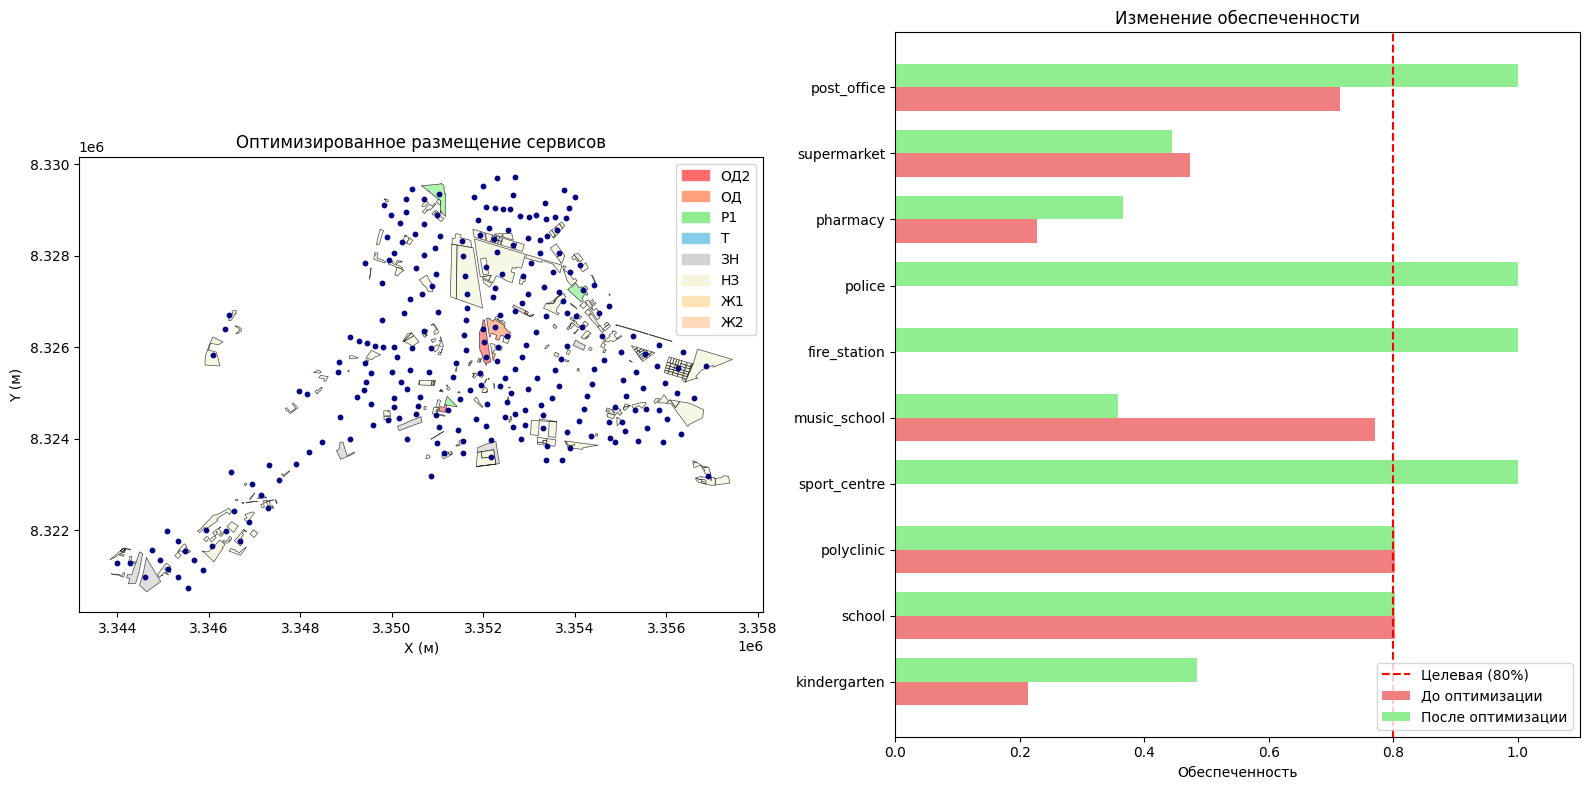

✓ Визуализация сохранена: optimization_results.png


In [ ]:
# =============================================================================
# ЯЧЕЙКА 12: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Цвета для ФЗ
ZONE_COLORS = {
    'ОД2': '#FF6B6B',
    'ОД': '#FFA07A',
    'Р1': '#90EE90',
    'Т': '#87CEEB',
    'ЗН': '#D3D3D3',
    'НЗ': '#F5F5DC',
    'Ж1': '#FFE4B5',
    'Ж2': '#FFDAB9'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Карта размещения
ax1 = axes[0]
ax1.set_title('Оптимизированное размещение сервисов', fontsize=12)

# Отображение участков с ФЗ
for zone, color in ZONE_COLORS.items():
    zone_parcels = results_gdf[results_gdf['functional_zone'] == zone]
    if len(zone_parcels) > 0:
        zone_parcels.plot(ax=ax1, color=color, edgecolor='black', linewidth=0.5, alpha=0.7)

# Центры кварталов
blocks.geometry.centroid.plot(ax=ax1, color='navy', markersize=10, label='Кварталы')

# Легенда
patches = [mpatches.Patch(color=color, label=zone) for zone, color in ZONE_COLORS.items()]
ax1.legend(handles=patches, loc='upper right')
ax1.set_xlabel('X (м)')
ax1.set_ylabel('Y (м)')

# Статистика по сервисам
ax2 = axes[1]
ax2.set_title('Изменение обеспеченности', fontsize=12)

services = list(results.keys())[:10]  # Первые 10 сервисов
initial = [results[s]['initial_avg_provision'] for s in services]
final = [results[s]['final_avg_provision'] for s in services]

x = np.arange(len(services))
width = 0.35

bars1 = ax2.barh(x - width/2, initial, width, label='До оптимизации', color='lightcoral')
bars2 = ax2.barh(x + width/2, final, width, label='После оптимизации', color='lightgreen')

ax2.axvline(x=0.8, color='red', linestyle='--', label='Целевая (80%)')
ax2.set_yticks(x)
ax2.set_yticklabels(services)
ax2.set_xlabel('Обеспеченность')
ax2.set_xlim(0, 1.1)
ax2.legend()

plt.tight_layout()
plt.savefig('optimization_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Визуализация сохранена: optimization_results.png")

In [ ]:
# =============================================================================
# ЯЧЕЙКА 13: СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
# =============================================================================

# Сводка по размещенным объектам
placement_summary = []

for placement in optimizer.all_placements:
    placement_summary.append({
        'Участок ID': placement.parcel_id,
        'Сервис': placement.service_type,
        'Вместимость': round(placement.capacity),
        'Площадь (м²)': round(placement.area_used),
        'Функц. зона': placement.functional_zone,
        'В жилой зоне': 'Да' if placement.keeps_residential else 'Нет',
        'Оценка': round(placement.total_score, 3)
    })

placement_df = pd.DataFrame(placement_summary)
print("\nРАЗМЕЩЕННЫЕ ОБЪЕКТЫ:")
print(placement_df.to_string())

# Сохранение в CSV
placement_df.to_csv('placed_services.csv', index=False, encoding='utf-8-sig')
print("\n✓ Таблица сохранена: placed_services.csv")

# Сводка по функциональным зонам
zone_summary = results_gdf.groupby('functional_zone').agg({
    'parcel_id': 'count',
    'total_area': 'sum',
    'used_area': 'sum',
    'num_services': 'sum'
}).rename(columns={
    'parcel_id': 'Участков',
    'total_area': 'Общая площадь',
    'used_area': 'Использовано',
    'num_services': 'Объектов'
}).round(0)

print("\nСВОДКА ПО ФУНКЦИОНАЛЬНЫМ ЗОНАМ:")
print(zone_summary.to_string())


РАЗМЕЩЕННЫЕ ОБЪЕКТЫ:
    Участок ID        Сервис  Вместимость  Площадь (м²) Функц. зона В жилой зоне  Оценка
0          111  kindergarten          274         10960         ОД2          Нет   1.072
1          224  sport_centre            1          3500         ОД2          Нет   0.727
2           26  music_school           50          1000         ОД2          Нет   0.647
3           97  fire_station            1          1000          ОД          Нет   0.784
4          175        police            1          1000          ОД          Нет   0.779
5          221      pharmacy          322           200          Ж1           Да   0.888
6          182   supermarket          500          1000          Ж1           Да   0.669
7          132   supermarket          500          1000          Ж1           Да   0.827
8          105   supermarket          131          1000          Ж1           Да   0.885
9          224   post_office            1           800          ОД          Нет   0.777